In [24]:
#0. Setup
import polars as pl
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gc
from pathlib import Path
from datetime import datetime, timezone
from scipy import stats as scipy_stats
from matplotlib.colors import LogNorm

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100


def ts2dt(ts_us):
    return datetime.fromtimestamp(ts_us / 1e6, tz=timezone.utc)

DATA = Path('liquidation_task/data') 

P = {
    'tr_btc':  DATA / 'binance_trades'       / 'perp_btcusdt.parquet',
    'tr_eth':  DATA / 'binance_trades'       / 'perp_ethusdt.parquet',
    'bbo_btc': DATA / 'binance_booktickers'  / 'perp_btcusdt.parquet',
    'bbo_eth': DATA / 'binance_booktickers'  / 'perp_ethusdt.parquet',
    'lb_btc':  DATA / 'binance_liquidations' / 'perp_btcusdt.parquet',
    'lb_eth':  DATA / 'binance_liquidations' / 'perp_ethusdt.parquet',
    'ly_btc':  DATA / 'bybit_liquidations'   / 'btcusdt.parquet',
    'ly_eth':  DATA / 'bybit_liquidations'   / 'ethusdt.parquet',
}

In [15]:
#1.1.1 Date ranges
for name, path in P.items():
    s = pl.scan_parquet(path).select(
        pl.col('timestamp').min().alias('mn'),
        pl.col('timestamp').max().alias('mx')
    ).collect()
    dt_min, dt_max = ts2dt(s['mn'][0]), ts2dt(s['mx'][0])
    print(f"{name:10s} | {dt_min} : {dt_max} | {(dt_max - dt_min).days}d")

tr_btc     | 2025-12-01 00:00:00.047000+00:00 : 2026-02-28 23:59:59.992000+00:00 | 89d
tr_eth     | 2025-12-01 00:00:00.016000+00:00 : 2026-02-28 23:59:59.993000+00:00 | 89d
bbo_btc    | 2025-12-01 00:00:02.075000+00:00 : 2026-02-28 23:59:59.949000+00:00 | 89d
bbo_eth    | 2025-12-01 00:00:00.683000+00:00 : 2026-02-28 23:59:59.829000+00:00 | 89d
lb_btc     | 2025-12-01 00:00:06.091000+00:00 : 2026-02-28 23:59:10.548000+00:00 | 89d
lb_eth     | 2025-12-01 00:00:09.455000+00:00 : 2026-02-28 23:49:50.541000+00:00 | 89d
ly_btc     | 2025-12-01 00:00:02.915000+00:00 : 2026-02-28 23:58:42.271000+00:00 | 89d
ly_eth     | 2025-12-01 00:00:07.779000+00:00 : 2026-02-28 23:34:22.075000+00:00 | 89d


In [5]:
#1.1.2 Null check
total_nulls = 0
for name, path in P.items():
    lf = pl.scan_parquet(path)
    for col in lf.collect_schema().names():
        n = lf.select(pl.col(col).is_null().sum()).collect()[col][0]
        if n > 0:
            print(f"{name:10s} | {col}: {n} nulls")
        total_nulls += n
print(f"Nulls: {total_nulls}")

Nulls: 0


In [18]:
#1.1.3 Duplicates
for name, path in P.items():
    sz = path.stat().st_size / 1e6
    n_rows = pq.ParquetFile(path).metadata.num_rows
    lf = pl.scan_parquet(path)
    if sz < 50:
        n_uniq = lf.unique().select(pl.len()).collect()[0, 0]
        n_dup = n_rows - n_uniq

    else:
        n_dup = (
            lf.select('timestamp')
            .group_by('timestamp').agg(pl.len().alias('c'))
            .filter(pl.col('c') > 1)
            .select(pl.col('c').sum() - pl.len())
            .collect(engine="streaming")[0, 0]
        )
    if n_dup > 0:
        print(f"{name:10s} | {n_dup:>12,} dups ({n_dup/n_rows*100:.2f}%)")

tr_btc     |  316,865,596 dups (78.84%)
tr_eth     |  597,583,948 dups (84.66%)
ly_btc     |            1 dups (0.00%)
ly_eth     |            2 dups (0.00%)


In [6]:
#1.1.4 Timestamp monotonicity
for name, path in P.items():
    n_bad = pl.scan_parquet(path).select(
        (pl.col('timestamp') < pl.col('timestamp').shift(1)).sum().alias('n')
    ).collect()['n'][0]
    if n_bad > 0:
        print(f"{name:10s} | {n_bad} out of order rows")

ly_btc     | 63 out of order rows
ly_eth     | 46 out of order rows


In [7]:
#1.1.5 Price & amount sanity
for name, path in P.items():
    lf = pl.scan_parquet(path)
    cols = lf.collect_schema().names()
    pc = 'price' if 'price' in cols else 'bid_price'
    ac = 'amount' if 'amount' in cols else 'bid_amount'
    s = lf.select(
        (pl.col(pc) <= 0).sum().alias('bad_p'),
        (pl.col(ac) <= 0).sum().alias('bad_a'),
    ).collect()
    if s['bad_p'][0] > 0 or s['bad_a'][0] > 0:
        print(f"{name:10s} | bad prices: {s['bad_p'][0]}, bad amounts: {s['bad_a'][0]}")
print("All prices and amounts positive")

All prices and amounts positive


In [10]:
#1.1.6 Event frequency
import math
for name, path in P.items():
    n = pq.ParquetFile(path).metadata.num_rows
    s = pl.scan_parquet(path).select(
        pl.col('timestamp').min().alias('mn'), pl.col('timestamp').max().alias('mx')
    ).collect()
    span = (s['mx'][0] - s['mn'][0]) / 1e6
    eps = n / span
    print(f"{name:10s} | {n:>15,} rows | {eps:>8.2f} evt/s | avg gap {1000/eps if eps>0 else 0:.1f}ms")

tr_btc     |     401,902,513 rows |    51.68 evt/s | avg gap 19.3ms
tr_eth     |     705,880,385 rows |    90.78 evt/s | avg gap 11.0ms
bbo_btc    |      99,169,477 rows |    12.75 evt/s | avg gap 78.4ms
bbo_eth    |     107,797,036 rows |    13.86 evt/s | avg gap 72.1ms
lb_btc     |         114,255 rows |     0.01 evt/s | avg gap 68057.8ms
lb_eth     |         131,769 rows |     0.02 evt/s | avg gap 59007.7ms
ly_btc     |         228,655 rows |     0.03 evt/s | avg gap 34007.2ms
ly_eth     |         160,214 rows |     0.02 evt/s | avg gap 48525.4ms


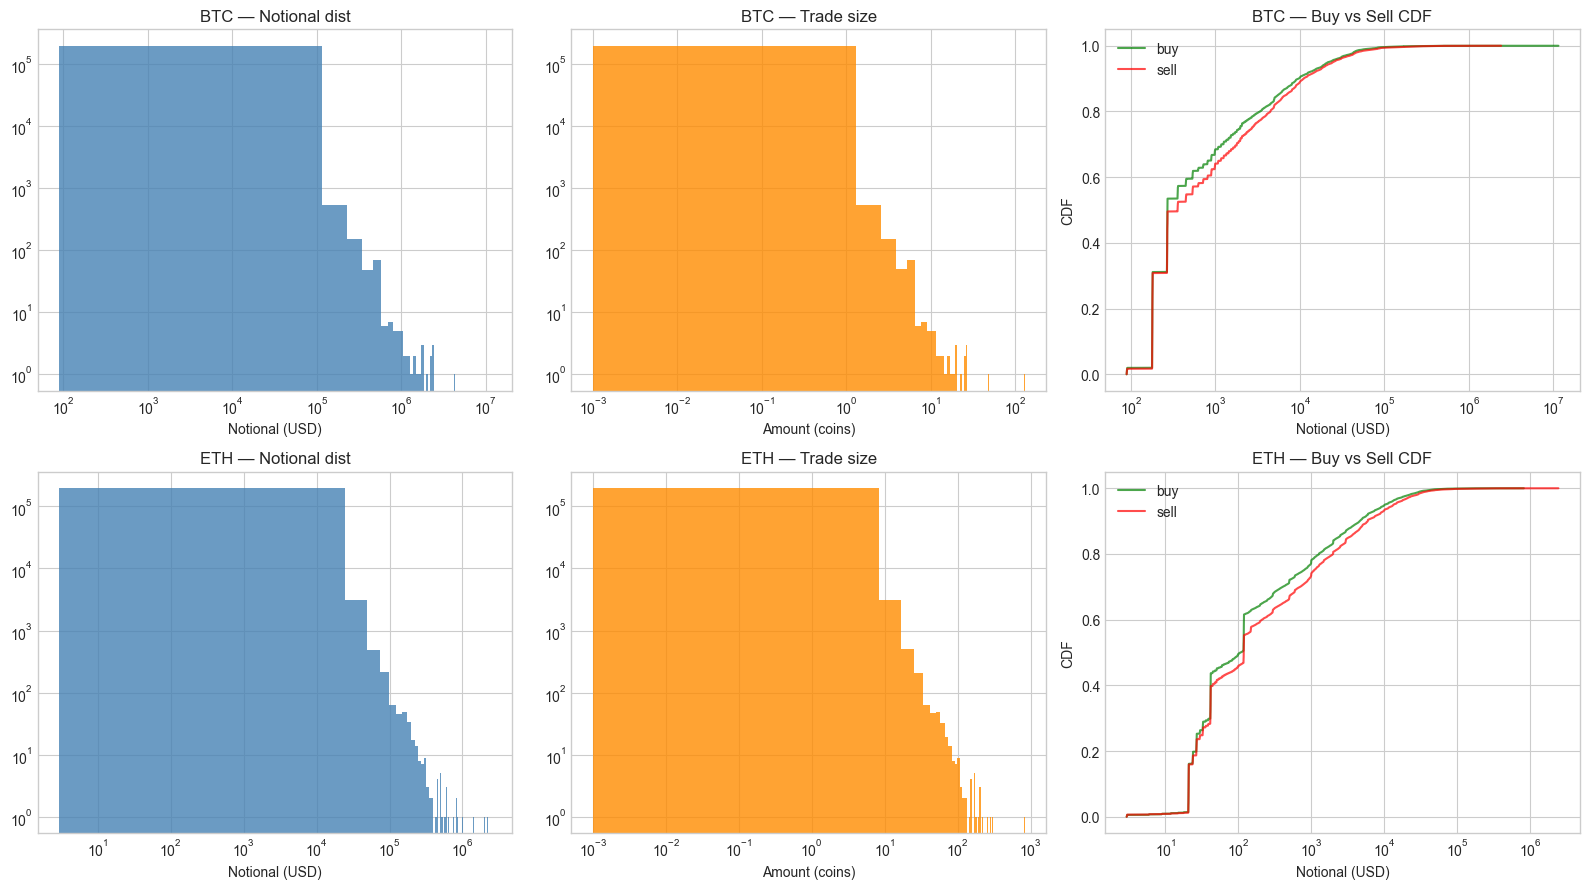

BTC: shape: (1, 5)
┌─────────────┬────────┬────────────┬───────────┬─────────────┐
│ mean        ┆ p50    ┆ p95        ┆ p99       ┆ max         │
│ ---         ┆ ---    ┆ ---        ┆ ---       ┆ ---         │
│ f64         ┆ f64    ┆ f64        ┆ f64       ┆ f64         │
╞═════════════╪════════╪════════════╪═══════════╪═════════════╡
│ 2996.470244 ┆ 254.85 ┆ 12976.0858 ┆ 51141.324 ┆ 5.4155481e7 │
└─────────────┴────────┴────────────┴───────────┴─────────────┘
ETH: shape: (1, 5)
┌─────────────┬──────────┬────────────┬─────────────┬──────────┐
│ mean        ┆ p50      ┆ p95        ┆ p99         ┆ max      │
│ ---         ┆ ---      ┆ ---        ┆ ---         ┆ ---      │
│ f64         ┆ f64      ┆ f64        ┆ f64         ┆ f64      │
╞═════════════╪══════════╪════════════╪═════════════╪══════════╡
│ 1555.204182 ┆ 40.24944 ┆ 7239.55155 ┆ 27219.25328 ┆ 2.7914e7 │
└─────────────┴──────────┴────────────┴─────────────┴──────────┘


In [2]:
#1.1.7 Trade size distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (sym, path) in enumerate([('BTC', P['tr_btc']), ('ETH', P['tr_eth'])]):
    df = pl.read_parquet(path, n_rows=200000)
    df = df.with_columns((pl.col('price') * pl.col('amount')).alias('ntl'))
    ntl = df['ntl'].to_numpy()
    amt = df['amount'].to_numpy()
    sides = df['side'].to_list()
    del df; gc.collect()

    axes[row, 0].hist(ntl, bins=100, log=True, color='steelblue', alpha=0.8)
    axes[row, 0].set_xscale('log')
    axes[row, 0].set(xlabel='Notional (USD)', title=f'{sym} — Notional dist')

    axes[row, 1].hist(amt, bins=100, log=True, color='darkorange', alpha=0.8)
    axes[row, 1].set_xscale('log')
    axes[row, 1].set(xlabel='Amount (coins)', title=f'{sym} — Trade size')

    for side, c in [('buy', 'green'), ('sell', 'red')]:
        sub = np.sort(ntl[[s == side for s in sides]])
        axes[row, 2].plot(sub, np.linspace(0, 1, len(sub)), label=side, color=c, alpha=0.7)
    axes[row, 2].set_xscale('log')
    axes[row, 2].set(xlabel='Notional (USD)', ylabel='CDF', title=f'{sym} — Buy vs Sell CDF')
    axes[row, 2].legend()

    del ntl, amt, sides; gc.collect()

plt.tight_layout()
plt.show()

for sym, path in [('BTC', P['tr_btc']), ('ETH', P['tr_eth'])]:
    s = pl.scan_parquet(path).select(
        (pl.col('price') * pl.col('amount')).alias('n')
    ).select([
        pl.col('n').mean().alias('mean'), pl.col('n').median().alias('p50'),
        pl.col('n').quantile(0.95).alias('p95'), pl.col('n').quantile(0.99).alias('p99'),
        pl.col('n').max().alias('max')
    ]).collect()
    print(f"{sym}: {s}")

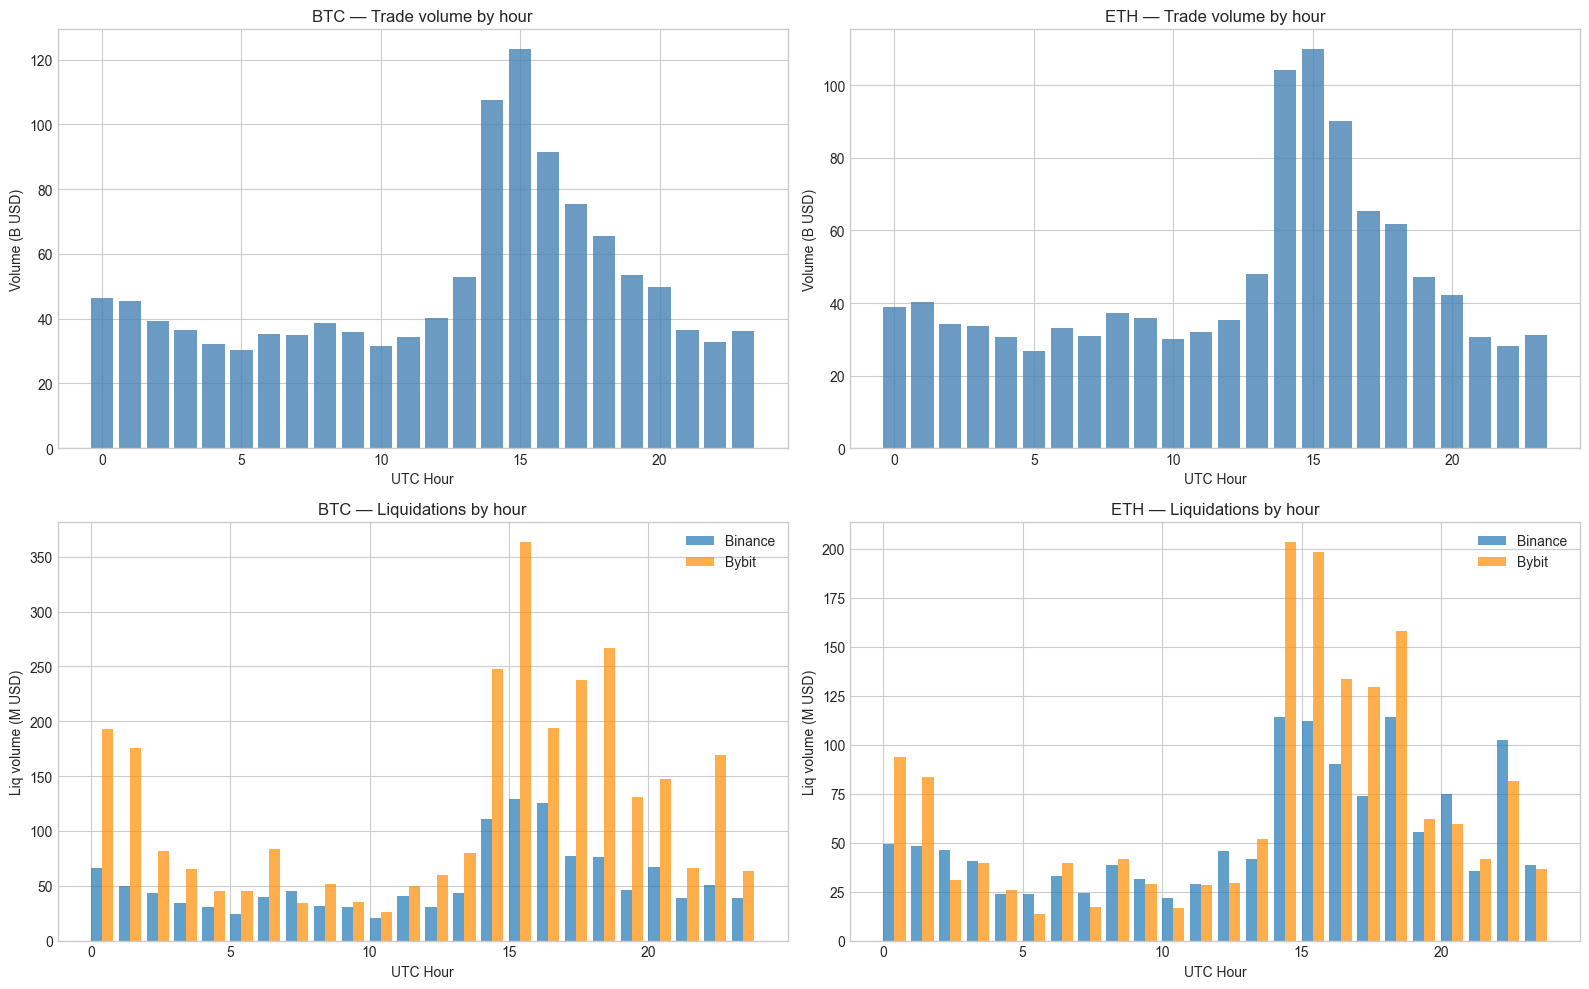

In [22]:
#1.1.8 Time of day patterns
def trades_hourly(path, chunk=5000000):
    hourly = {}
    for batch in pq.ParquetFile(path).iter_batches(batch_size=chunk, columns=['timestamp', 'price', 'amount']):
        df = pl.from_arrow(batch).with_columns([
            (pl.col('price') * pl.col('amount')).alias('ntl'),
            pl.col('timestamp').cast(pl.Datetime('us', 'UTC')).dt.hour().alias('h'),
        ])
        for r in df.group_by('h').agg(pl.col('ntl').sum()).iter_rows():
            hourly[r[0]] = hourly.get(r[0], 0) + r[1]
        del df, batch
    gc.collect()
    return pl.DataFrame({'h': list(hourly.keys()), 'ntl': list(hourly.values())}).sort('h')

def liq_hourly(path):
    return pl.read_parquet(path).with_columns([
        (pl.col('price') * pl.col('amount')).alias('ntl'),
        pl.col('timestamp').cast(pl.Datetime('us', 'UTC')).dt.hour().alias('h'),
    ]).group_by('h').agg(pl.col('ntl').sum().alias('ntl')).sort('h')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (sym, tp, lbp, lyp) in enumerate([
    ('BTC', P['tr_btc'], P['lb_btc'], P['ly_btc']),
    ('ETH', P['tr_eth'], P['lb_eth'], P['ly_eth'])
]):
    th = trades_hourly(tp)
    lb = liq_hourly(lbp)
    ly = liq_hourly(lyp)

    axes[0, col].bar(th['h'].to_numpy(), th['ntl'].to_numpy() / 1e9, color='steelblue', alpha=0.8)
    axes[0, col].set(xlabel='UTC Hour', ylabel='Volume (B USD)', title=f'{sym} Trade volume by hour')

    axes[1, col].bar(lb['h'].to_numpy(), lb['ntl'].to_numpy()/1e6, alpha=0.7, label='Binance', width=0.4, align='edge')
    axes[1, col].bar(ly['h'].to_numpy()+0.4, ly['ntl'].to_numpy()/1e6, alpha=0.7, label='Bybit', color='darkorange', width=0.4, align='edge')
    axes[1, col].set(xlabel='UTC Hour', ylabel='Liq volume (M USD)', title=f'{sym} Liquidations by hour')
    axes[1, col].legend()

    del th; gc.collect()

plt.tight_layout()
plt.show()

BTC Binance:
  sell= 64,209  buy= 50,046
  p50=     1,116  p99=   163,353  max=    15,054,962
BTC Bybit:
  sell=153,798  buy= 74,857
  p50=     1,118  p99=   200,303  max=     3,439,243
ETH Binance:
  sell= 73,474  buy= 58,295
  p50=       728  p99=   148,860  max=    15,482,568
ETH Bybit:
  sell=112,667  buy= 47,547
  p50=       912  p99=   179,385  max=     3,793,963


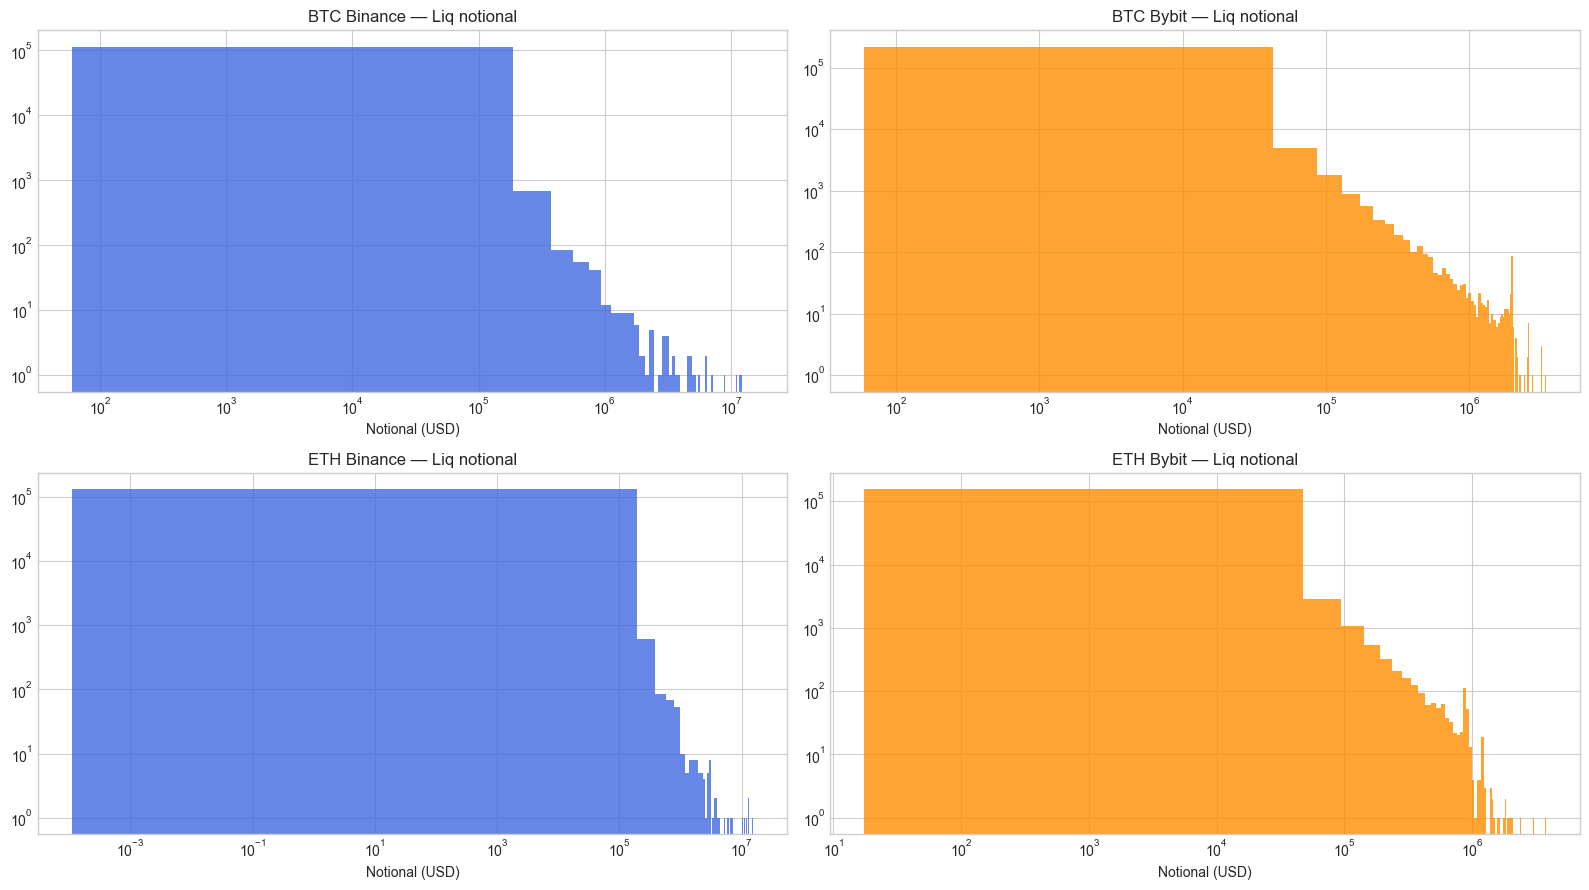

In [20]:
#1.1.9 Liquidation distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for row, sym in enumerate(['btc', 'eth']):
    for ci, (exch, key, clr) in enumerate([('Binance', f'lb_{sym}', 'royalblue'), ('Bybit', f'ly_{sym}', 'darkorange')]):
        df = pl.read_parquet(P[key]).with_columns((pl.col('price') * pl.col('amount')).alias('ntl'))

        axes[row, ci].hist(df['ntl'].to_numpy(), bins=80, log=True, color=clr, alpha=0.8)
        axes[row, ci].set_xscale('log')
        axes[row, ci].set(xlabel='Notional (USD)', title=f'{sym.upper()} {exch} — Liq notional')

        sc = df.group_by('side').agg(pl.len().alias('n')).sort('side')
        sides = dict(zip(sc['side'].to_list(), sc['n'].to_list()))
        print(f"{sym.upper()} {exch}:")
        print(f"  sell={sides.get('sell', 0):>7,}  buy={sides.get('buy', 0):>7,}")
        print(f"  p50={df['ntl'].quantile(0.5):>10,.0f}  p99={df['ntl'].quantile(0.99):>10,.0f}  max={df['ntl'].max():>14,.0f}")

plt.tight_layout()
plt.show()

BTC: volume corr=0.829, count corr=0.886
ETH: volume corr=0.745, count corr=0.817


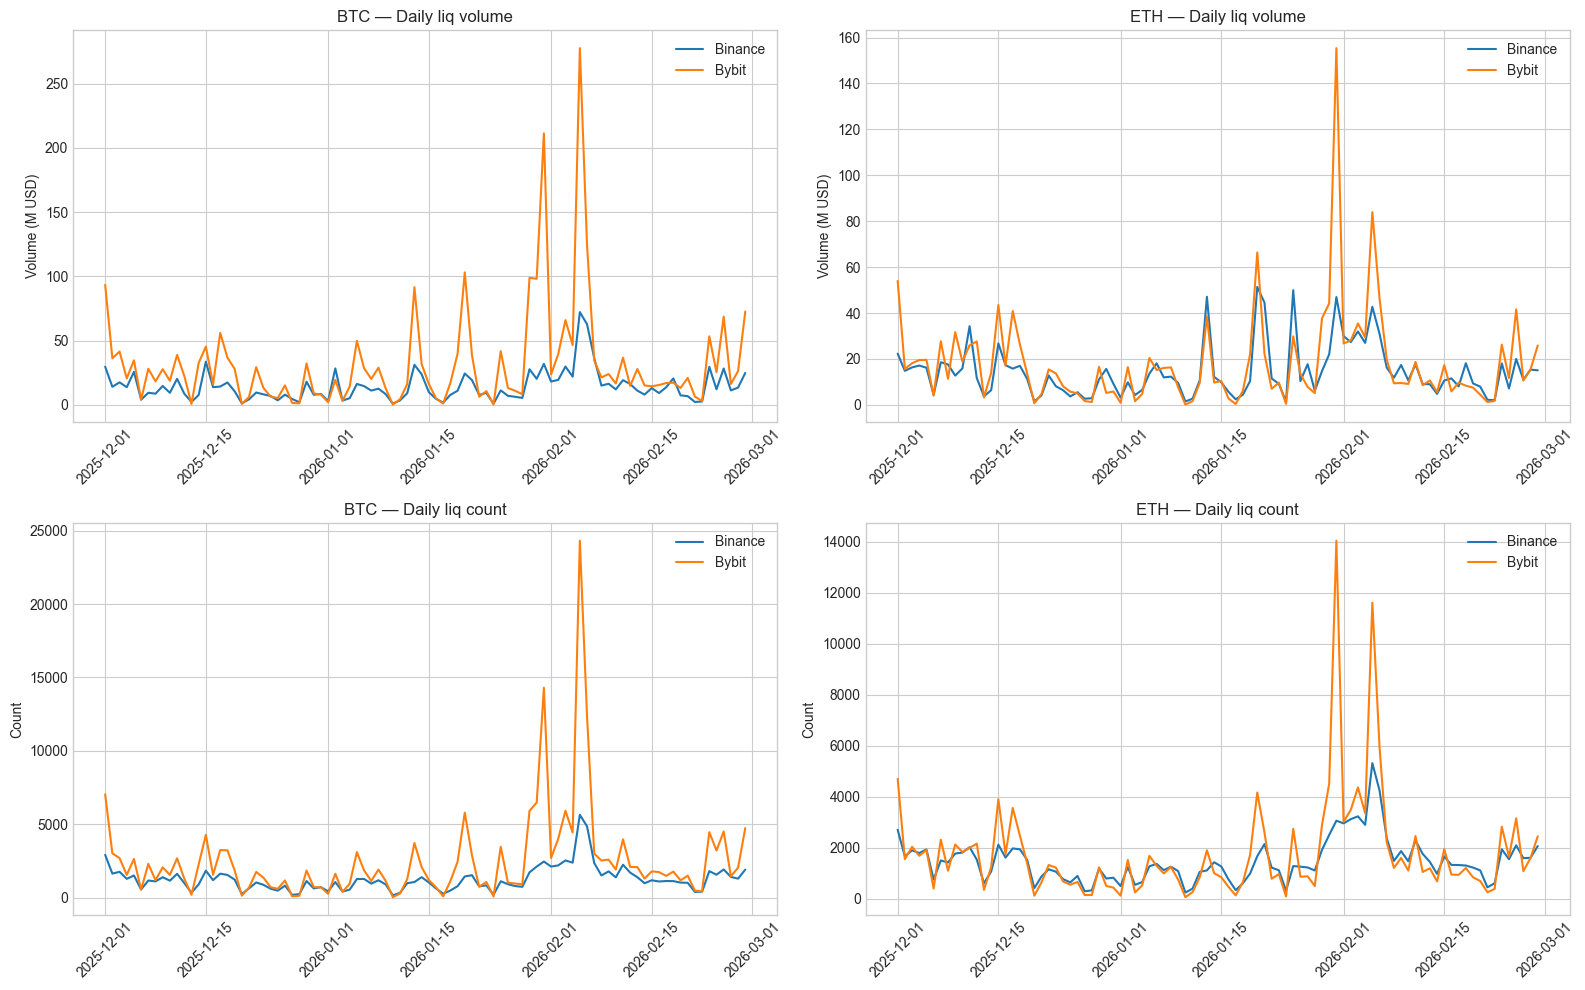

In [19]:
#1.1.10 Cross-exchange: daily liquidation volume and correlation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for col, sym in enumerate(['btc', 'eth']):
    def daily_liq(path):
        return pl.read_parquet(path).with_columns([
            (pl.col('price') * pl.col('amount')).alias('ntl'),
            pl.col('timestamp').cast(pl.Datetime('us', 'UTC')).dt.date().alias('d'),
        ]).group_by('d').agg([pl.col('ntl').sum().alias('vol'), pl.len().alias('cnt')]).sort('d')
    bd = daily_liq(P[f'lb_{sym}'])
    yd = daily_liq(P[f'ly_{sym}'])
    axes[0, col].plot(bd['d'].to_list(), bd['vol'].to_numpy()/1e6, label='Binance')
    axes[0, col].plot(yd['d'].to_list(), yd['vol'].to_numpy()/1e6, label='Bybit')
    axes[0, col].set(ylabel='Volume (M USD)', title=f'{sym.upper()} — Daily liq volume')
    axes[0, col].legend(); axes[0, col].tick_params(axis='x', rotation=45)
    axes[1, col].plot(bd['d'].to_list(), bd['cnt'].to_numpy(), label='Binance')
    axes[1, col].plot(yd['d'].to_list(), yd['cnt'].to_numpy(), label='Bybit')
    axes[1, col].set(ylabel='Count', title=f'{sym.upper()} — Daily liq count')
    axes[1, col].legend(); axes[1, col].tick_params(axis='x', rotation=45)
    mg = bd.join(yd, on='d', suffix='_y')
    cv = np.corrcoef(mg['vol'].to_numpy(), mg['vol_y'].to_numpy())[0,1]
    cc = np.corrcoef(mg['cnt'].to_numpy(), mg['cnt_y'].to_numpy())[0,1]
    print(f"{sym.upper()}: volume corr={cv:.3f}, count corr={cc:.3f}")
plt.tight_layout()
plt.show()

BTC: mean imbalance = 0.137 (sell-heavy)
ETH: mean imbalance = 0.134 (sell-heavy)


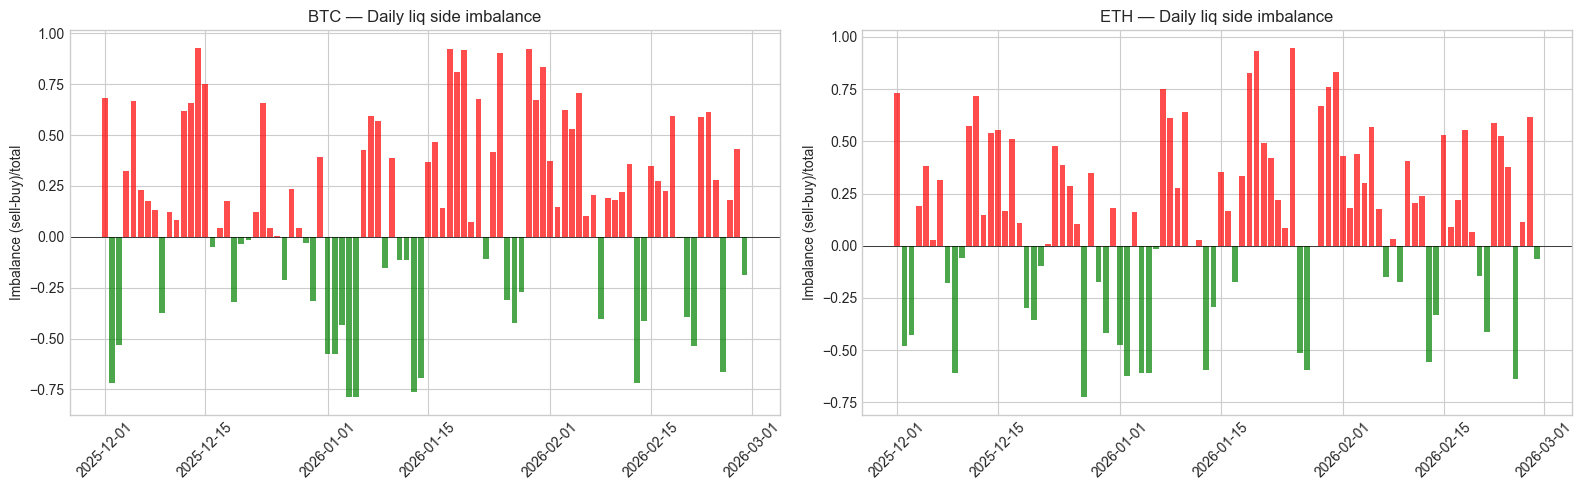

In [6]:
#1.1.11 Cross-exchange: liquidation side imbalance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col, sym in enumerate(['btc', 'eth']):
    frames = [pl.read_parquet(P[k]).with_columns([
        (pl.col('price') * pl.col('amount')).alias('ntl'),
        pl.col('timestamp').cast(pl.Datetime('us', 'UTC')).dt.date().alias('d'),
    ]) for k in [f'lb_{sym}', f'ly_{sym}']]
    all_liq = pl.concat(frames)

    ds = all_liq.group_by(['d', 'side']).agg(pl.col('ntl').sum().alias('v')).sort('d')
    bv = ds.filter(pl.col('side') == 'buy').sort('d')
    sv = ds.filter(pl.col('side') == 'sell').sort('d')
    mg = bv.join(sv, on='d', suffix='_s')
    imb = (mg['v_s'] - mg['v']) / (mg['v_s'] + mg['v'])

    axes[col].bar(mg['d'].to_list(), imb.to_numpy(),
                  color=['red' if v > 0 else 'green' for v in imb.to_list()], alpha=0.7)
    axes[col].axhline(0, color='black', lw=0.5)
    axes[col].set(ylabel='Imbalance (sell-buy)/total', title=f'{sym.upper()} — Daily liq side imbalance')
    axes[col].tick_params(axis='x', rotation=45)
    print(f"{sym.upper()}: mean imbalance = {imb.mean():.3f} ({'sell-heavy' if imb.mean() > 0 else 'buy-heavy'})")

plt.tight_layout()
plt.show()

### Summary  Task 1.1

Data quality:
- Zero nulls across all datasets. All prices and amounts strictly positive.
- Shared timestamps in trades (78–85%) are expected — exchange batch matching, not duplicates.
- Bybit liquidations have minor issues: 63/46 out-of-order timestamps, 1–2 exact duplicates. Sort before use.

Univariate analysis:
- BTC median trade notional = $255, mean = $2,997 — extreme right skew (max $54M).
- ETH median = $40, mean = $1,555 (max $28M). Most trades are small retail, mean pulled up by rare large blocks.
- Buy vs Sell CDFs are nearly identical — no systematic size asymmetry.
- Event frequency: trades 50–90/sec, BBO 13/sec, liquidations 0.02/sec.

Cross-exchange comparison:
- Binance–Bybit daily liquidation correlation: volume ρ=0.83 (BTC) / 0.75 (ETH), count ρ=0.89/0.82.
- Sell liquidations dominate on both exchanges (2:1 ratio, mean imbalance +0.13) — persistent long-side bias.
- Bybit has 2× more events; Binance has larger single events (max $15M vs $3.4M).


BTC: abs spread mean=0.1302, median=0.1000
  bps: mean=0.0150, median=0.0116, p99=0.0674
  locked=0, crossed=0
ETH: abs spread mean=0.0120, median=0.0100
  bps: mean=0.0421, median=0.0353, p99=0.1712
  locked=0, crossed=0


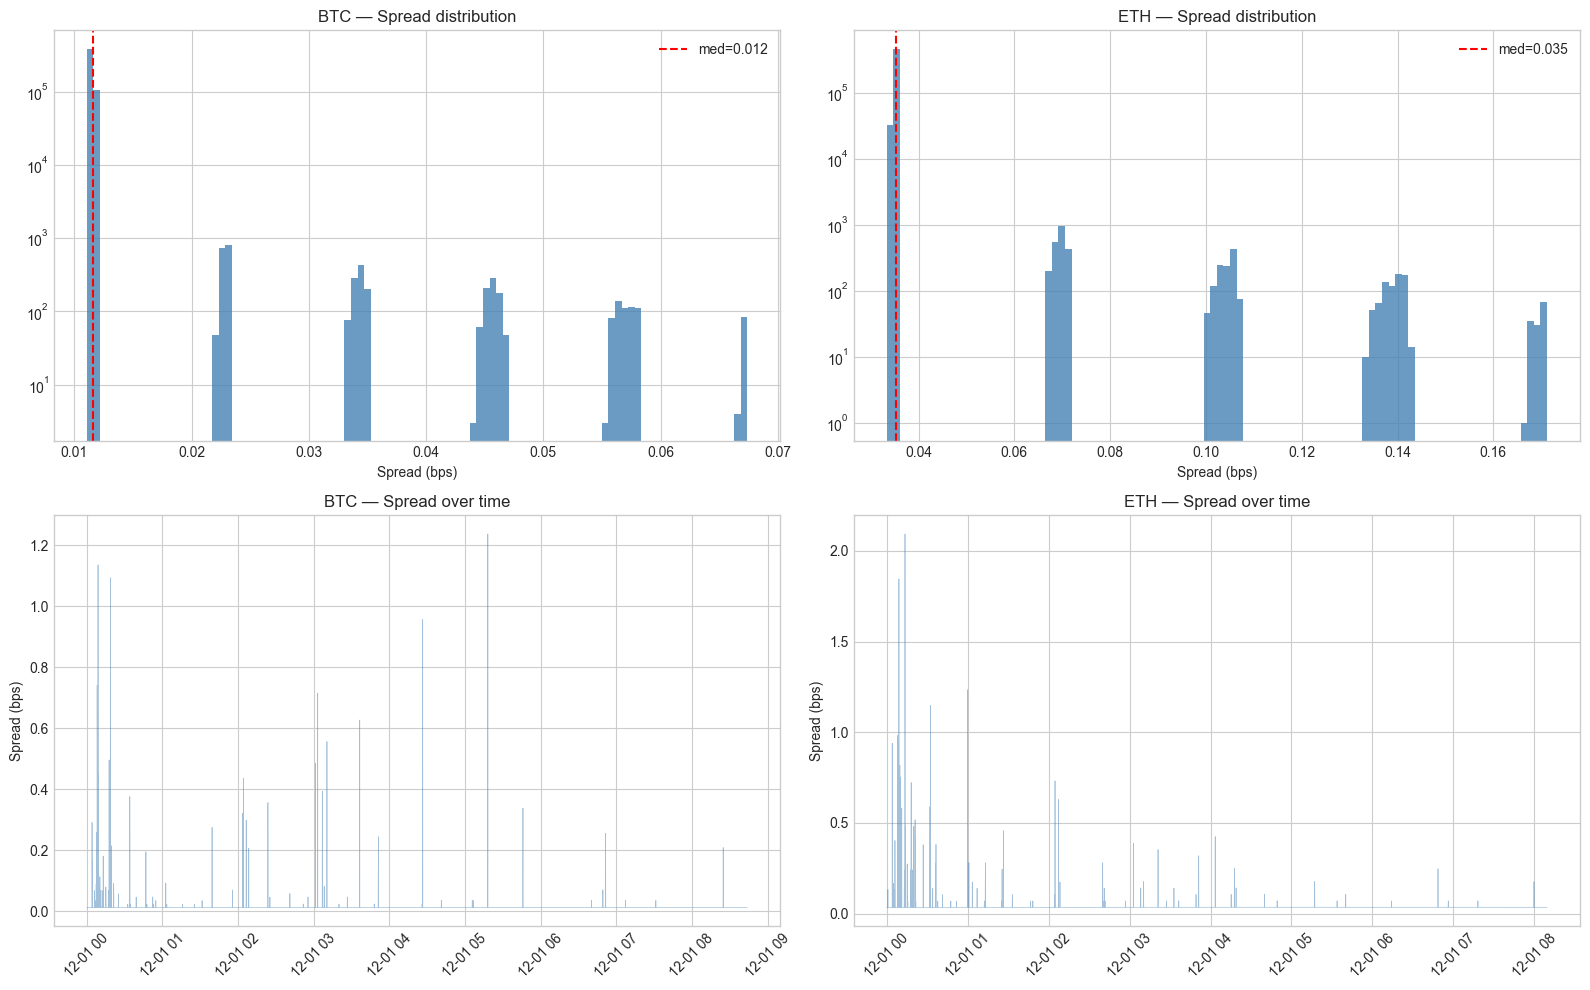

In [7]:
#1.2.1 Spread analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (sym, path) in enumerate([('BTC', P['bbo_btc']), ('ETH', P['bbo_eth'])]):
    df = pl.read_parquet(path, n_rows=500000).with_columns([
        (pl.col('ask_price') - pl.col('bid_price')).alias('spr'),
        ((pl.col('ask_price') - pl.col('bid_price')) / ((pl.col('ask_price') + pl.col('bid_price'))/2) * 10000).alias('spr_bps'),
    ])
    sb = df['spr_bps'].to_numpy()
    sa = df['spr'].to_numpy()

    print(f"{sym}: abs spread mean={sa.mean():.4f}, median={np.median(sa):.4f}")
    print(f"  bps: mean={sb.mean():.4f}, median={np.median(sb):.4f}, p99={np.percentile(sb, 99):.4f}")
    print(f"  locked={int((sa==0).sum())}, crossed={int((sa<0).sum())}")

    axes[0, col].hist(sb[sb < np.percentile(sb, 99)], bins=100, color='steelblue', alpha=0.8, log=True)
    axes[0, col].axvline(np.median(sb), color='red', ls='--', label=f'med={np.median(sb):.3f}')
    axes[0, col].set(xlabel='Spread (bps)', title=f'{sym} — Spread distribution')
    axes[0, col].legend()

    ts = df['timestamp'].cast(pl.Datetime('us', 'UTC')).to_numpy()
    step = max(1, len(ts)//5000)
    axes[1, col].plot(ts[::step], sb[::step], alpha=0.5, lw=0.5, color='steelblue')
    axes[1, col].set(ylabel='Spread (bps)', title=f'{sym} — Spread over time')
    axes[1, col].tick_params(axis='x', rotation=45)

    del df, sb, sa, ts; gc.collect()

plt.tight_layout()
plt.show()

BTC: buy_ratio=0.4963, daily_vol=13.38B +/- 6.91B
ETH: buy_ratio=0.4975, daily_vol=12.20B +/- 5.91B


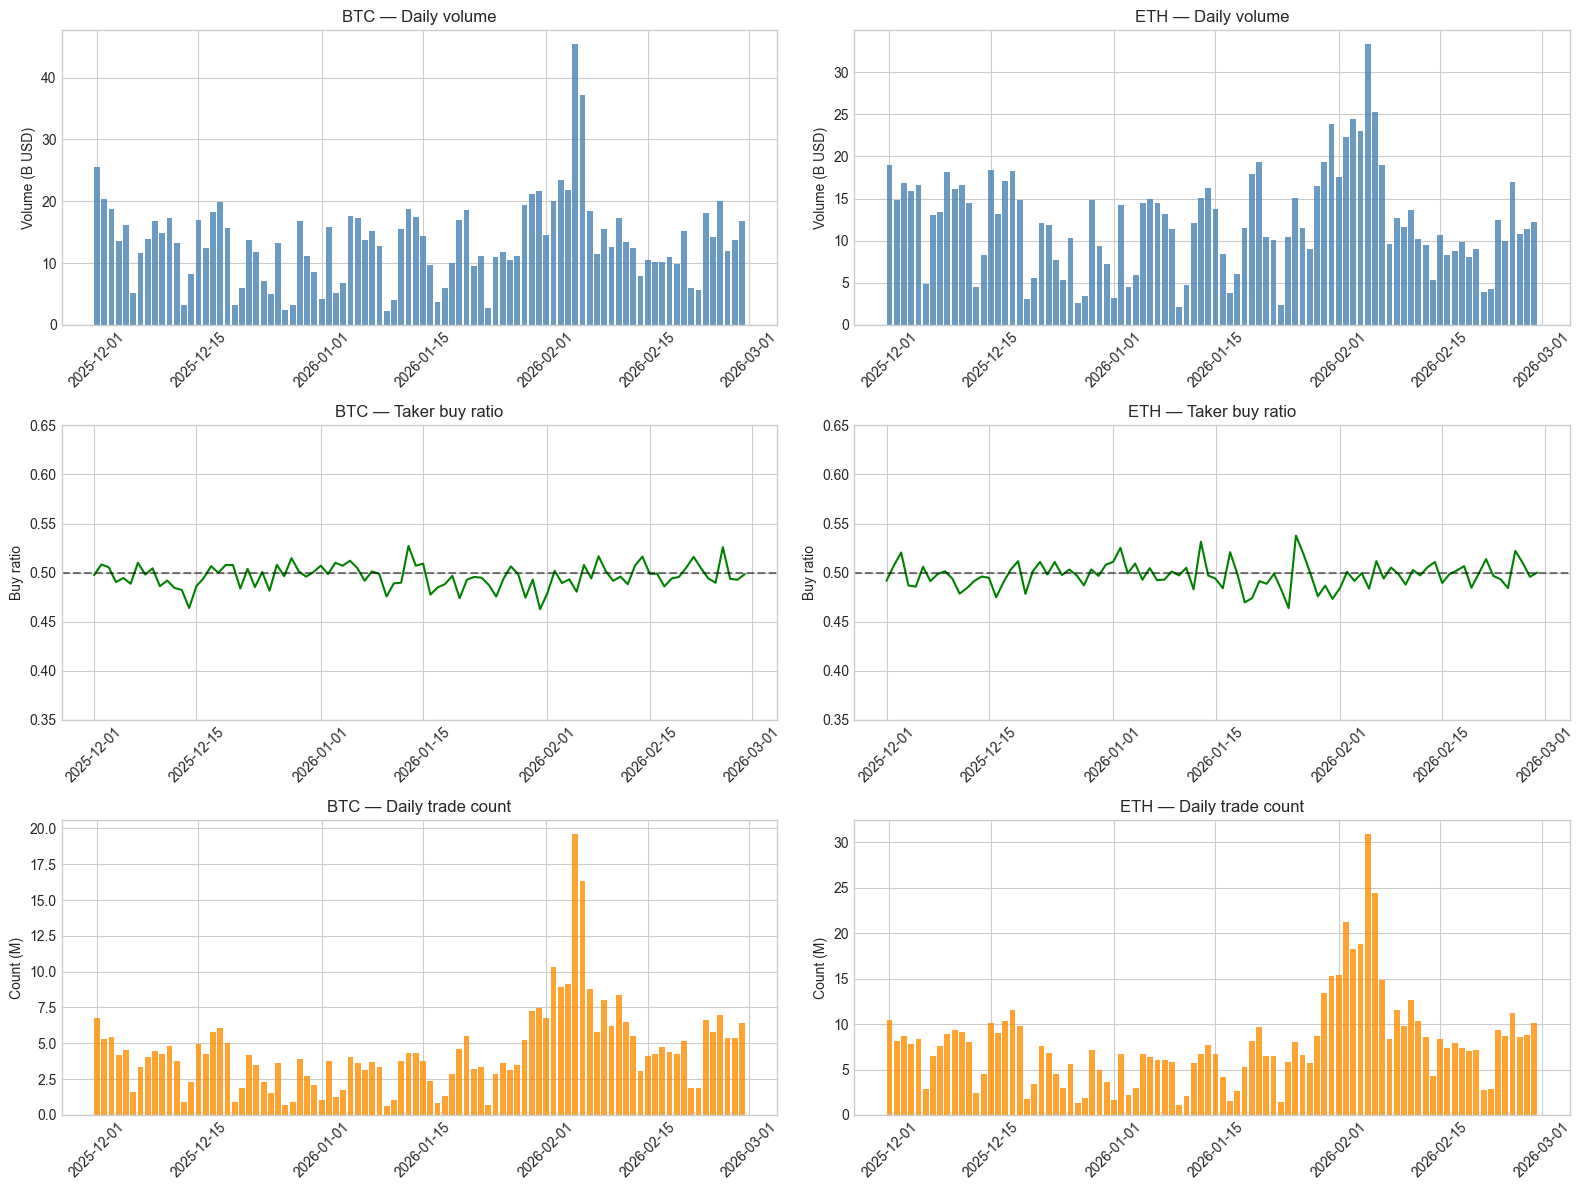

In [8]:
#1.2.2 Trade statistics: daily volume and taker buy ratio
def trade_stats(path, chunk=5000000):
    daily = {}
    for batch in pq.ParquetFile(path).iter_batches(batch_size=chunk, columns=['timestamp', 'price', 'amount', 'side']):
        df = pl.from_arrow(batch).with_columns([
            (pl.col('price') * pl.col('amount')).alias('ntl'),
            pl.col('timestamp').cast(pl.Datetime('us', 'UTC')).dt.date().alias('d'),
        ])
        for r in df.group_by(['d', 'side']).agg([pl.col('ntl').sum().alias('v'), pl.len().alias('c')]).iter_rows():
            d, side, v, c = r
            if d not in daily: daily[d] = {'bv': 0, 'sv': 0, 'bc': 0, 'sc': 0}
            daily[d][f"{'b' if side=='buy' else 's'}v"] += v
            daily[d][f"{'b' if side=='buy' else 's'}c"] += c
        del df, batch
    gc.collect()
    dates = sorted(daily.keys())
    return pl.DataFrame({
        'd': dates,
        'bv': [daily[d]['bv'] for d in dates], 'sv': [daily[d]['sv'] for d in dates],
        'bc': [daily[d]['bc'] for d in dates], 'sc': [daily[d]['sc'] for d in dates],
    }).with_columns([
        (pl.col('bv') + pl.col('sv')).alias('tv'),
        (pl.col('bc') + pl.col('sc')).alias('tc'),
        (pl.col('bv') / (pl.col('bv') + pl.col('sv'))).alias('br'),
    ])

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for col, (sym, path) in enumerate([('BTC', P['tr_btc']), ('ETH', P['tr_eth'])]):
    s = trade_stats(path)
    d = s['d'].to_list()

    axes[0, col].bar(d, s['tv'].to_numpy()/1e9, color='steelblue', alpha=0.8)
    axes[0, col].set(ylabel='Volume (B USD)', title=f'{sym} — Daily volume')
    axes[0, col].tick_params(axis='x', rotation=45)

    axes[1, col].plot(d, s['br'].to_numpy(), color='green')
    axes[1, col].axhline(0.5, color='black', ls='--', alpha=0.5)
    axes[1, col].set(ylabel='Buy ratio', title=f'{sym} — Taker buy ratio', ylim=(0.35, 0.65))
    axes[1, col].tick_params(axis='x', rotation=45)

    axes[2, col].bar(d, s['tc'].to_numpy()/1e6, color='darkorange', alpha=0.8)
    axes[2, col].set(ylabel='Count (M)', title=f'{sym} — Daily trade count')
    axes[2, col].tick_params(axis='x', rotation=45)

    print(f"{sym}: buy_ratio={s['br'].mean():.4f}, daily_vol={s['tv'].mean()/1e9:.2f}B +/- {s['tv'].std()/1e9:.2f}B")
    del s; gc.collect()

plt.tight_layout()
plt.show()

BTC: 772247 samples, price 59,936-97,860, ret std=2.92bps
  high-vol regime (>2x median): 13.5%
ETH: 773204 samples, price 1,747-3,445, ret std=4.15bps
  high-vol regime (>2x median): 14.0%


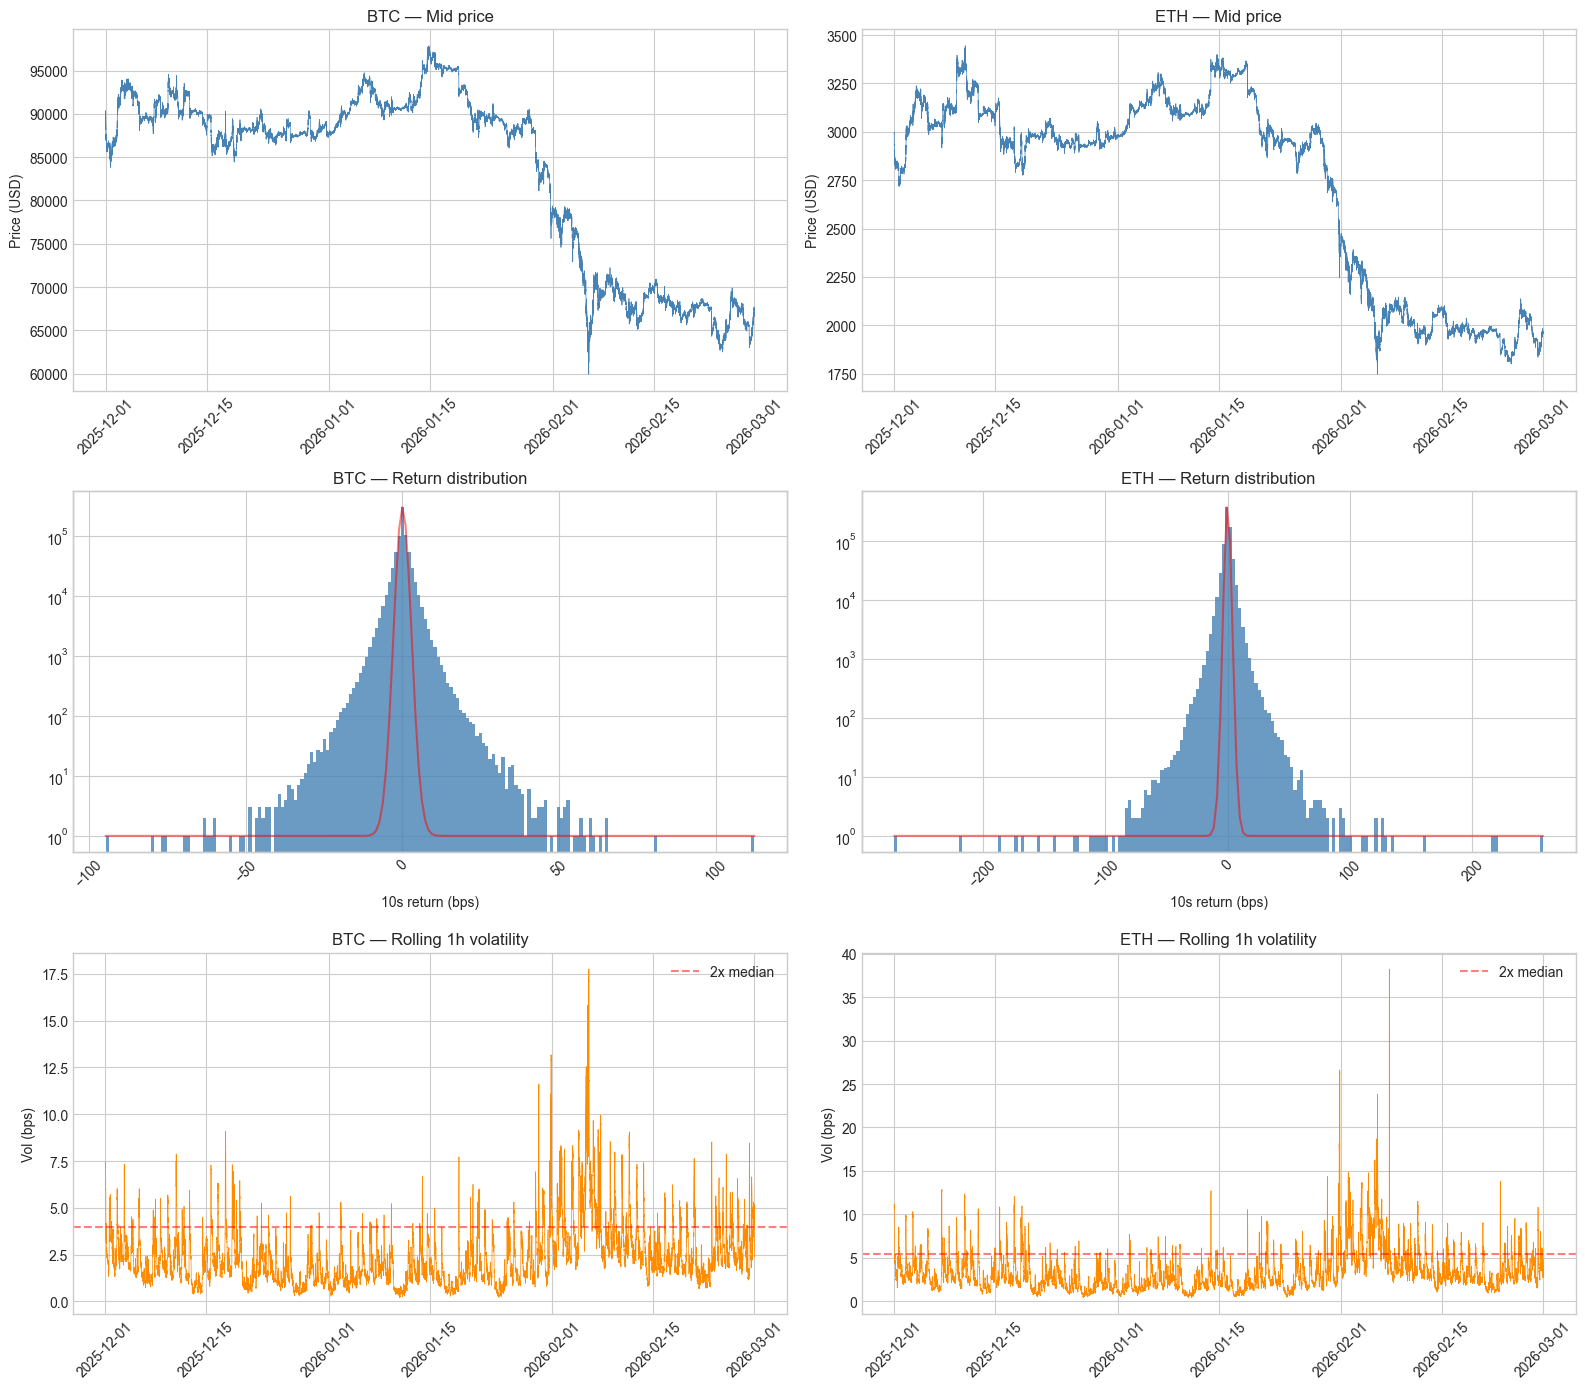

In [9]:
#1.2.3 Price regimes and volatility
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for col, (sym, bbo_path) in enumerate([('BTC', P['bbo_btc']), ('ETH', P['bbo_eth'])]):
    mids, timestamps = [], []
    last_ts = 0
    for batch in pq.ParquetFile(bbo_path).iter_batches(batch_size=2000000, columns=['timestamp', 'bid_price', 'ask_price']):
        df = pl.from_arrow(batch).with_columns(((pl.col('bid_price') + pl.col('ask_price'))/2).alias('mid'))
        for ts, mid in df.select(['timestamp', 'mid']).iter_rows():
            if ts - last_ts >= 10000000:  # 10s sampling
                timestamps.append(ts); mids.append(mid); last_ts = ts
        del df, batch
    gc.collect()

    mids = np.array(mids)
    ts_dt = [ts2dt(t) for t in timestamps]
    lr = np.diff(np.log(mids))

    w = 360  # 1h window
    rvol = np.array([lr[max(0,i-w):i].std() for i in range(w, len(lr))])

    print(f"{sym}: {len(mids)} samples, price {mids.min():,.0f}-{mids.max():,.0f}, ret std={lr.std()*1e4:.2f}bps")
    print(f"  high-vol regime (>2x median): {(rvol > np.median(rvol)*2).mean()*100:.1f}%")

    axes[0, col].plot(ts_dt, mids, lw=0.5, color='steelblue')
    axes[0, col].set(ylabel='Price (USD)', title=f'{sym} — Mid price')

    axes[1, col].hist(lr * 1e4, bins=200, log=True, color='steelblue', alpha=0.8)
    axes[1, col].set(xlabel='10s return (bps)', title=f'{sym} — Return distribution')
    x = np.linspace(lr.min()*1e4, lr.max()*1e4, 200)
    ax2 = axes[1, col].twinx()
    ax2.plot(x, scipy_stats.norm.pdf(x, lr.mean()*1e4, lr.std()*1e4), 'r-', alpha=0.5)
    ax2.set_yticks([])

    axes[2, col].plot(ts_dt[w+1:], rvol * 1e4, lw=0.5, color='darkorange')
    axes[2, col].axhline(np.median(rvol)*2*1e4, color='red', ls='--', alpha=0.5, label='2x median')
    axes[2, col].set(ylabel='Vol (bps)', title=f'{sym} — Rolling 1h volatility')
    axes[2, col].legend()

    for ax in axes[:, col]: ax.tick_params(axis='x', rotation=45)
    del mids, timestamps, ts_dt, lr, rvol; gc.collect()

plt.tight_layout()
plt.show()

BTC: ret ACF(1)=0.0824, ACF(5)=0.0009
  |ret| ACF(1)=0.3513, ACF(30)=0.2654, ACF(300)=0.2276
ETH: ret ACF(1)=0.0519, ACF(5)=-0.0055
  |ret| ACF(1)=0.3914, ACF(30)=0.2989, ACF(300)=0.2360


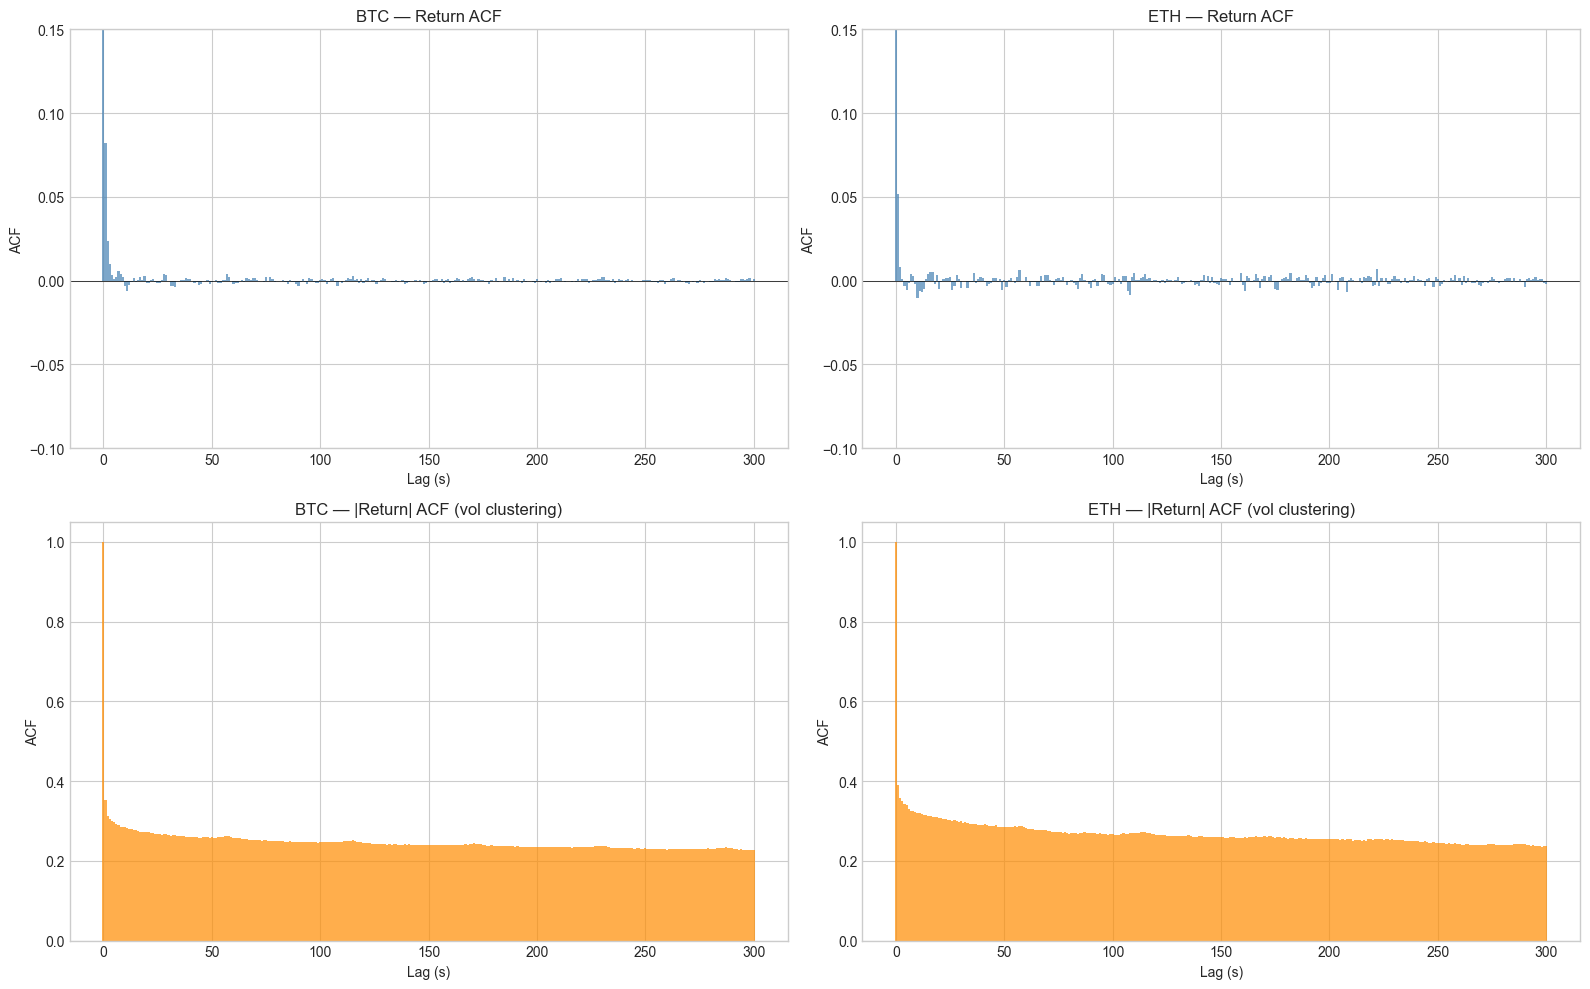

In [10]:
#1.2.4 Autocorrelation of returns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (sym, bbo_path) in enumerate([('BTC', P['bbo_btc']), ('ETH', P['bbo_eth'])]):
    mids = []
    last_ts = 0
    for batch in pq.ParquetFile(bbo_path).iter_batches(batch_size=2000000, columns=['timestamp', 'bid_price', 'ask_price']):
        df = pl.from_arrow(batch).with_columns(((pl.col('bid_price') + pl.col('ask_price'))/2).alias('mid'))
        for ts, mid in df.select(['timestamp', 'mid']).iter_rows():
            if ts - last_ts >= 1000000:  # 1s sampling
                mids.append(mid); last_ts = ts
        del df, batch
    gc.collect()

    mids = np.array(mids)
    lr = np.diff(np.log(mids))
    ar = np.abs(lr)

    max_lag = 300
    acf_r = [np.corrcoef(lr[:-l], lr[l:])[0,1] if l > 0 else 1.0 for l in range(max_lag+1)]
    acf_a = [np.corrcoef(ar[:-l], ar[l:])[0,1] if l > 0 else 1.0 for l in range(max_lag+1)]

    axes[0, col].bar(range(max_lag+1), acf_r, width=1, color='steelblue', alpha=0.7)
    axes[0, col].set(xlabel='Lag (s)', ylabel='ACF', title=f'{sym} — Return ACF', ylim=(-0.1, 0.15))
    axes[0, col].axhline(0, color='black', lw=0.5)

    axes[1, col].bar(range(max_lag+1), acf_a, width=1, color='darkorange', alpha=0.7)
    axes[1, col].set(xlabel='Lag (s)', ylabel='ACF', title=f'{sym} — |Return| ACF (vol clustering)')

    print(f"{sym}: ret ACF(1)={acf_r[1]:.4f}, ACF(5)={acf_r[5]:.4f}")
    print(f"  |ret| ACF(1)={acf_a[1]:.4f}, ACF(30)={acf_a[30]:.4f}, ACF(300)={acf_a[300]:.4f}")

    del mids, lr, ar; gc.collect()

plt.tight_layout()
plt.show()

  BTC t= 30s: mean=-0.249bps, std=18.93, SNR=0.0131
  BTC t=120s: mean=+5.433bps, std=30.79, SNR=0.1764
  BTC t=300s: mean=+11.540bps, std=61.64, SNR=0.1872


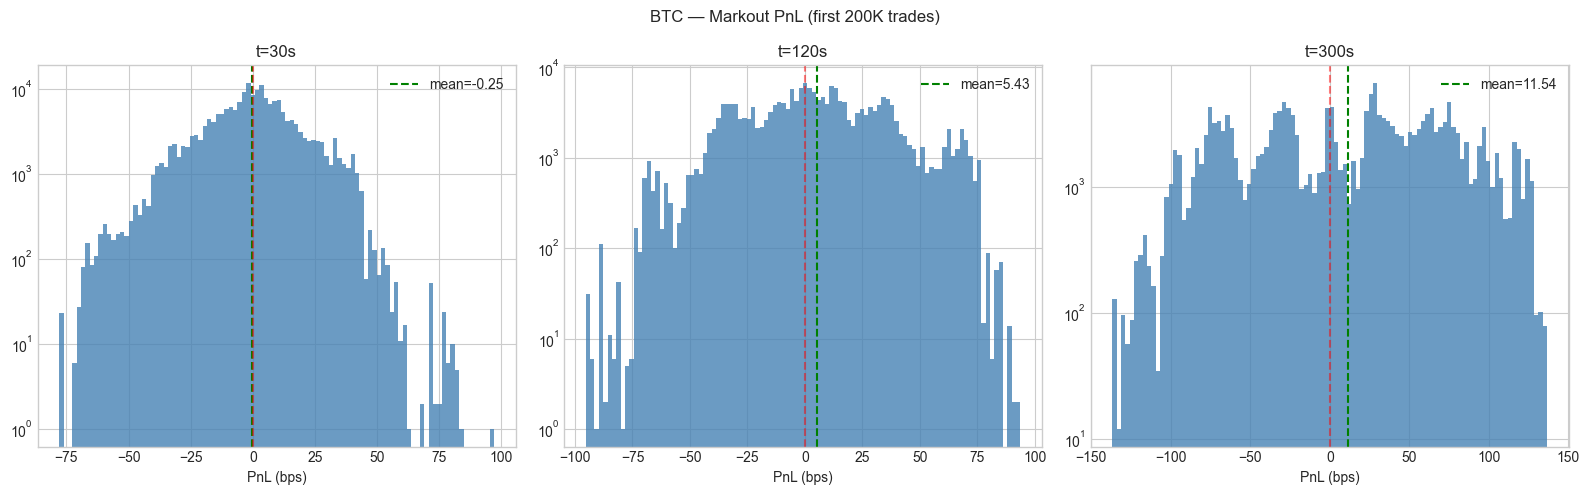

  ETH t= 30s: mean=-0.339bps, std=24.26, SNR=0.0140
  ETH t=120s: mean=+8.983bps, std=66.03, SNR=0.1360
  ETH t=300s: mean=+21.709bps, std=148.92, SNR=0.1458


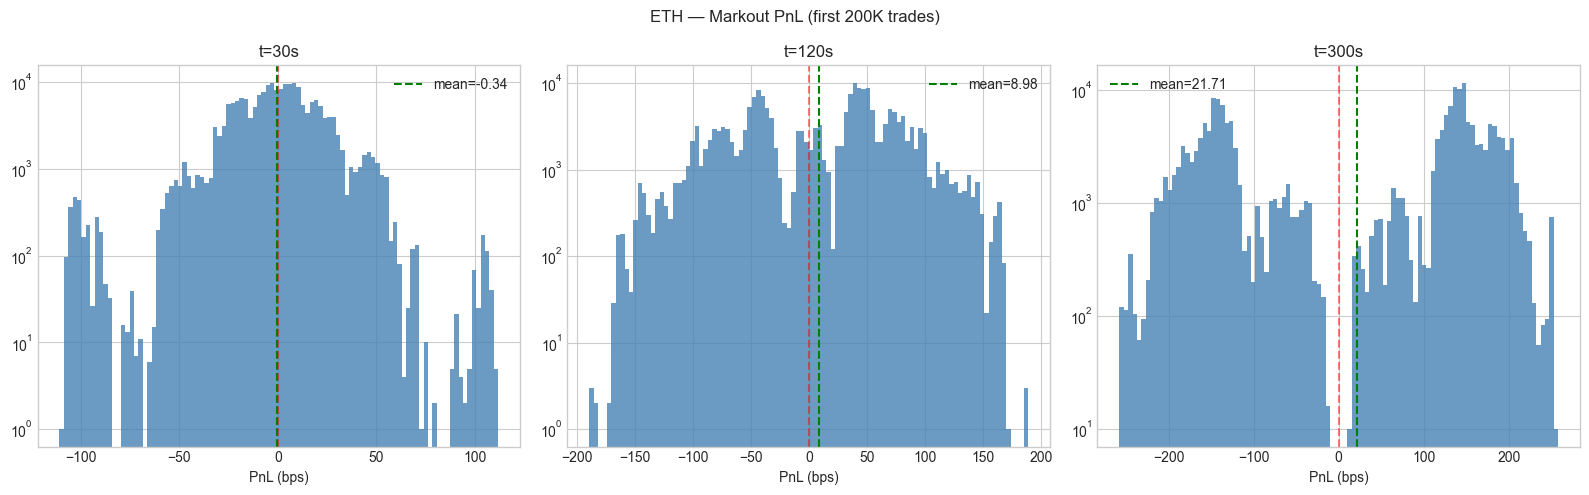

In [11]:
#1.2.5 Markout PnL target variable preview
for sym, tp, bp in [('BTC', P['tr_btc'], P['bbo_btc']), ('ETH', P['tr_eth'], P['bbo_eth'])]:
    trades = pl.read_parquet(tp, n_rows=200000)
    t_min, t_max = trades['timestamp'].min(), trades['timestamp'].max()

    bbo = pl.scan_parquet(bp).filter(
        (pl.col('timestamp') >= t_min) & (pl.col('timestamp') <= t_max + 301000000)
    ).select(['timestamp', 'bid_price', 'ask_price']).with_columns(
        ((pl.col('bid_price') + pl.col('ask_price'))/2).alias('mid')
    ).select(['timestamp', 'mid']).collect()

    bts = bbo['timestamp'].to_numpy()
    bmid = bbo['mid'].to_numpy()
    tts = trades['timestamp'].to_numpy()
    tp_ = trades['price'].to_numpy()
    tsd = trades['side'].to_list()
    del trades, bbo; gc.collect()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{sym} — Markout PnL (first 200K trades)')

    for i, tau in enumerate([30, 120, 300]):
        pnls = []
        for j in range(len(tts)):
            idx = np.searchsorted(bts, tts[j] + tau * 1000000, side='right') - 1
            if 0 <= idx < len(bmid):
                si = -1 if tsd[j] == 'buy' else 1
                pnls.append(-si * (bmid[idx] - tp_[j]) / tp_[j] * 10000 + 0.5)

        pnls = np.array(pnls)
        snr = abs(pnls.mean()) / pnls.std() if pnls.std() > 0 else 0
        print(f"  {sym} t={tau:3d}s: mean={pnls.mean():+.3f}bps, std={pnls.std():.2f}, SNR={snr:.4f}")

        axes[i].hist(pnls, bins=100, log=True, color='steelblue', alpha=0.8)
        axes[i].axvline(pnls.mean(), color='green', ls='--', label=f'mean={pnls.mean():.2f}')
        axes[i].axvline(0, color='red', ls='--', alpha=0.5)
        axes[i].set(xlabel='PnL (bps)', title=f't={tau}s')
        axes[i].legend()

    del bts, bmid, tts, tp_, tsd; gc.collect()
    plt.tight_layout(); plt.show()

### Summary — Task 1.2

Market microstructure:
- BTC spread median = 0.012 bps ($0.10), ETH = 0.035 bps ($0.01) — minimum tick size, ultra-tight.
- No locked or crossed quotes — data is clean.
- Taker buy ratio ~0.497 — nearly symmetric flow, slight sell-side dominance.
- Daily volume: BTC $13.4B ± $6.9B, ETH $12.2B ± $5.9B — high day-to-day variance.

ML EDA:
- Volatility regimes: ~14% of time in high-vol regime (>2× median). Clear clustering visible on rolling vol chart.
- Return ACF: BTC ACF(1)=0.08, near-zero after lag 1 — market near-efficient at 1s scale.
- |Return| ACF: 0.35 at lag 1s, still 0.23 at lag 300s — strong volatility clustering persists 5+ minutes.
- Markout PnL at t=30s: −0.25 bps (BTC), −0.34 bps (ETH) — adverse selection dominates despite +0.5 bps rebate.
- Markout PnL at t=300s: +11.5 bps (BTC), +21.7 bps (ETH) — mean-reversion at longer horizons.
- SNR grows from 0.013 (t=30s) to 0.187 (t=300s) — signal weak but improvable with filtering.


## 1.3 Advanced Exploration

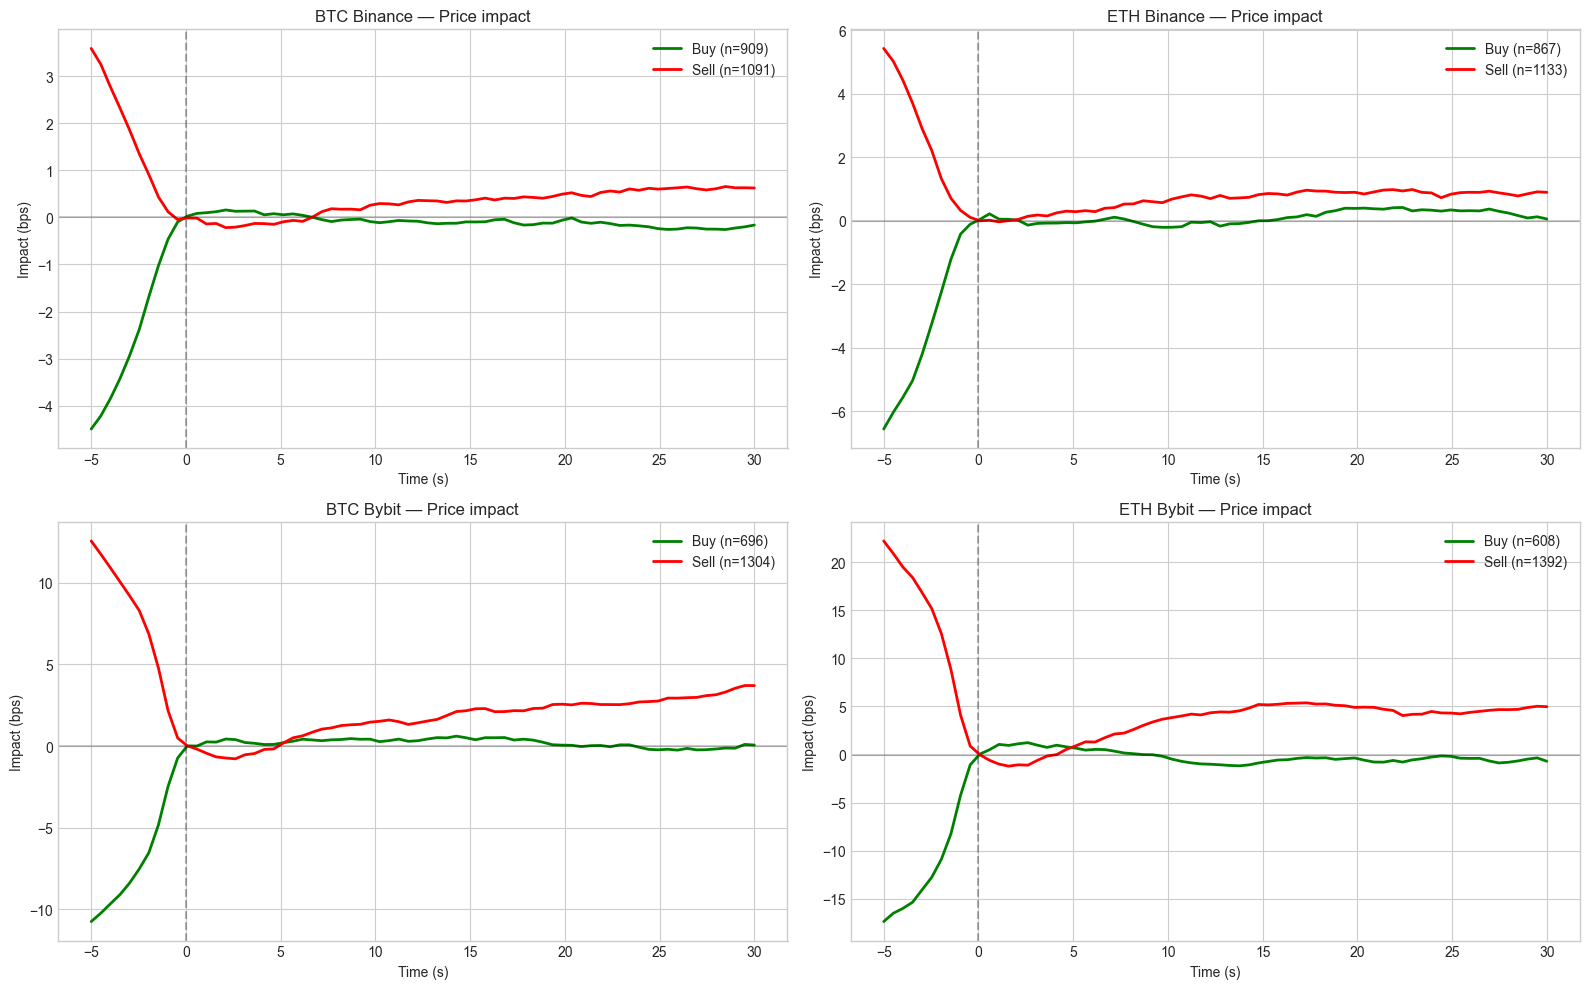

In [12]:
#1.3.1 Price impact around liquidation events
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, sym in enumerate(['btc', 'eth']):
    pf = pq.ParquetFile(P[f'bbo_{sym}'])
    bts_l, bmid_l = [], []
    last_ts = 0
    for batch in pf.iter_batches(batch_size=2000000, columns=['timestamp', 'bid_price', 'ask_price']):
        df = pl.from_arrow(batch).with_columns(((pl.col('bid_price') + pl.col('ask_price'))/2).alias('mid'))
        for ts, mid in df.select(['timestamp', 'mid']).iter_rows():
            if ts - last_ts >= 100000:
                bts_l.append(ts); bmid_l.append(mid); last_ts = ts
        del df, batch
    gc.collect()
    bts = np.array(bts_l); bmid = np.array(bmid_l)
    del bts_l, bmid_l

    for ri, (exch, lk) in enumerate([('Binance', f'lb_{sym}'), ('Bybit', f'ly_{sym}')]):
        liq = pl.read_parquet(P[lk]).sample(n=min(2000, pl.read_parquet(P[lk]).height), seed=42)
        offsets = np.linspace(-5000000, 30000000, 70)
        buy_imp, sell_imp = [], []

        for ts_l, _, side, _, _ in liq.iter_rows():
            idx_at = np.searchsorted(bts, ts_l, side='right') - 1
            if idx_at < 10 or idx_at >= len(bmid) - 10: continue
            mid_at = bmid[idx_at]
            if mid_at == 0: continue
            imp = [(bmid[np.searchsorted(bts, ts_l + int(o), side='right') - 1] - mid_at) / mid_at * 10000
                   if 0 <= np.searchsorted(bts, ts_l + int(o), side='right') - 1 < len(bmid) else np.nan
                   for o in offsets]
            (buy_imp if side == 'buy' else sell_imp).append(imp)

        ax = axes[ri, col]
        if buy_imp: ax.plot(offsets/1e6, np.nanmean(buy_imp, axis=0), color='green', lw=2, label=f'Buy (n={len(buy_imp)})')
        if sell_imp: ax.plot(offsets/1e6, np.nanmean(sell_imp, axis=0), color='red', lw=2, label=f'Sell (n={len(sell_imp)})')
        ax.axvline(0, color='black', ls='--', alpha=0.3); ax.axhline(0, color='black', alpha=0.2)
        ax.set(xlabel='Time (s)', ylabel='Impact (bps)', title=f'{sym.upper()} {exch} — Price impact')
        ax.legend()

    del bts, bmid; gc.collect()

plt.tight_layout()
plt.show()

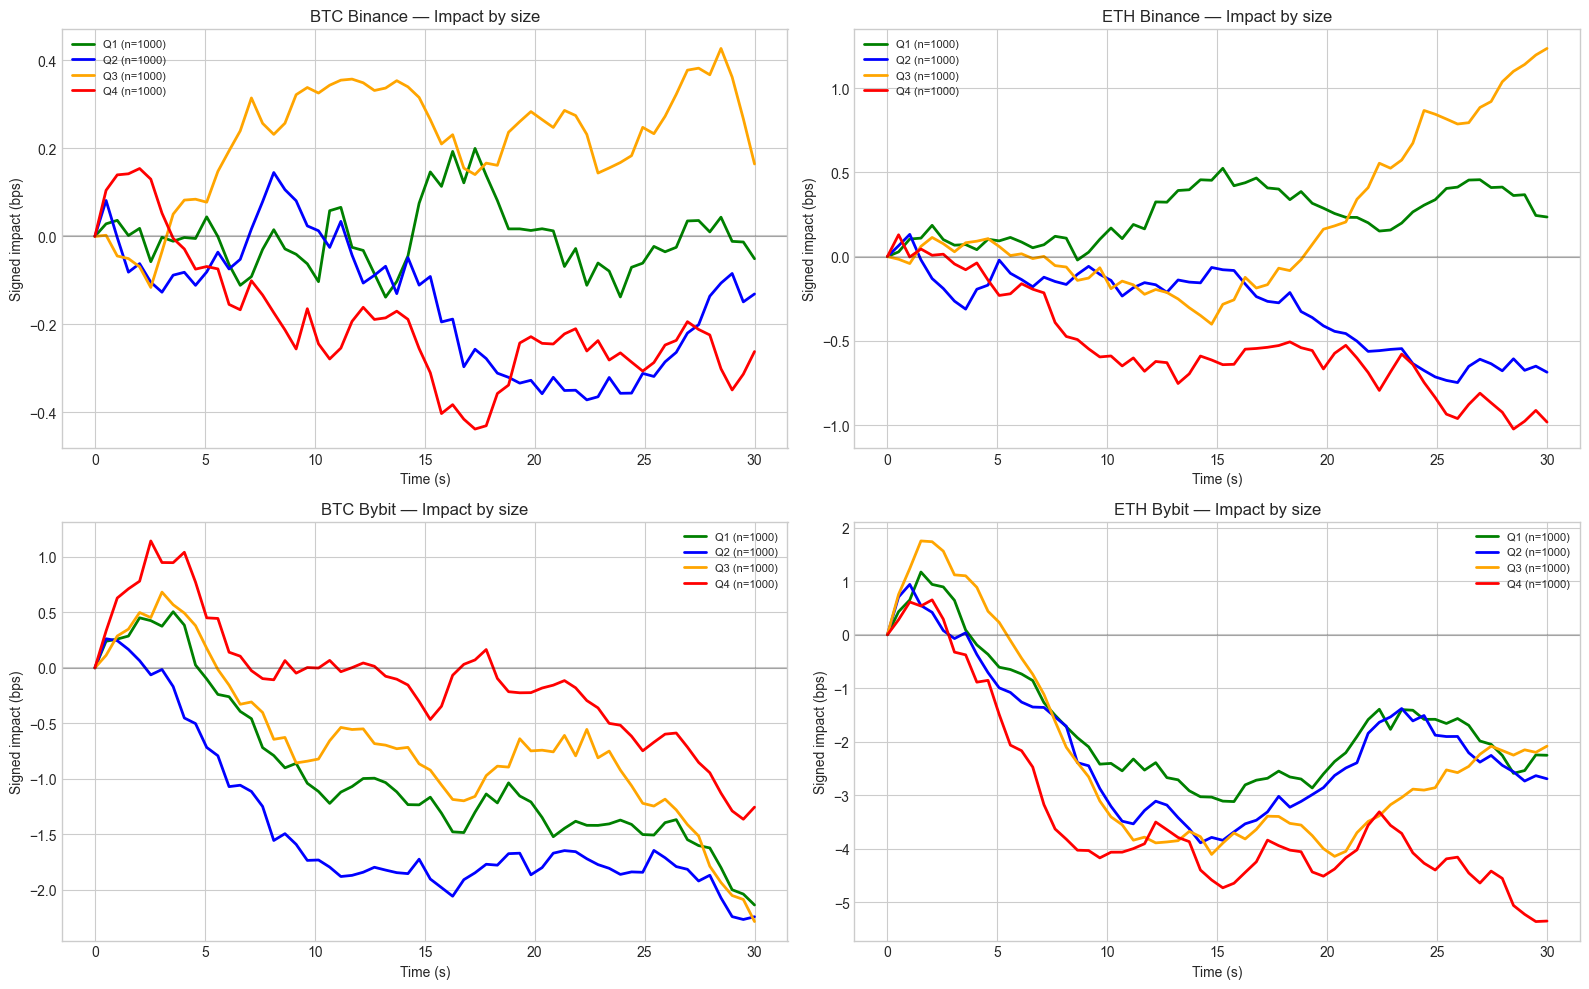

In [13]:
#1.3.2 Price impact by liquidation size quartile
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, sym in enumerate(['btc', 'eth']):
    pf = pq.ParquetFile(P[f'bbo_{sym}'])
    bts_l, bmid_l = [], []
    last_ts = 0
    for batch in pf.iter_batches(batch_size=2000000, columns=['timestamp', 'bid_price', 'ask_price']):
        df = pl.from_arrow(batch).with_columns(((pl.col('bid_price') + pl.col('ask_price'))/2).alias('mid'))
        for ts, mid in df.select(['timestamp', 'mid']).iter_rows():
            if ts - last_ts >= 100000:
                bts_l.append(ts); bmid_l.append(mid); last_ts = ts
        del df, batch
    gc.collect()
    bts = np.array(bts_l); bmid = np.array(bmid_l)
    del bts_l, bmid_l

    for ri, (exch, lk) in enumerate([('Binance', f'lb_{sym}'), ('Bybit', f'ly_{sym}')]):
        liq = pl.read_parquet(P[lk]).with_columns((pl.col('price') * pl.col('amount')).alias('ntl'))
        qs = [liq['ntl'].quantile(q) for q in [0.25, 0.5, 0.75]]
        quartiles = [
            ('Q1', liq.filter(pl.col('ntl') <= qs[0])),
            ('Q2', liq.filter((pl.col('ntl') > qs[0]) & (pl.col('ntl') <= qs[1]))),
            ('Q3', liq.filter((pl.col('ntl') > qs[1]) & (pl.col('ntl') <= qs[2]))),
            ('Q4', liq.filter(pl.col('ntl') > qs[2])),
        ]
        offsets = np.linspace(0, 30000000, 60)
        ax = axes[ri, col]
        for (ql, sub), clr in zip(quartiles, ['green', 'blue', 'orange', 'red']):
            sample = sub.sample(n=min(1000, len(sub)), seed=42)
            impacts = []
            for ts_l, _, side, _, _, _ in sample.iter_rows():
                idx_at = np.searchsorted(bts, ts_l, side='right') - 1
                if idx_at < 1 or idx_at >= len(bmid) - 1: continue
                mid_at = bmid[idx_at]
                if mid_at == 0: continue
                sign = 1 if side == 'buy' else -1
                impacts.append([sign * (bmid[np.searchsorted(bts, ts_l + int(o), side='right') - 1] - mid_at) / mid_at * 10000
                                if 0 <= np.searchsorted(bts, ts_l + int(o), side='right') - 1 < len(bmid) else np.nan
                                for o in offsets])
            if impacts: ax.plot(offsets/1e6, np.nanmean(impacts, axis=0), color=clr, lw=2, label=f'{ql} (n={len(impacts)})')
        ax.axhline(0, color='black', alpha=0.2)
        ax.set(xlabel='Time (s)', ylabel='Signed impact (bps)', title=f'{sym.upper()} {exch} — Impact by size')
        ax.legend(fontsize=8)
    del bts, bmid; gc.collect()

plt.tight_layout()
plt.show()

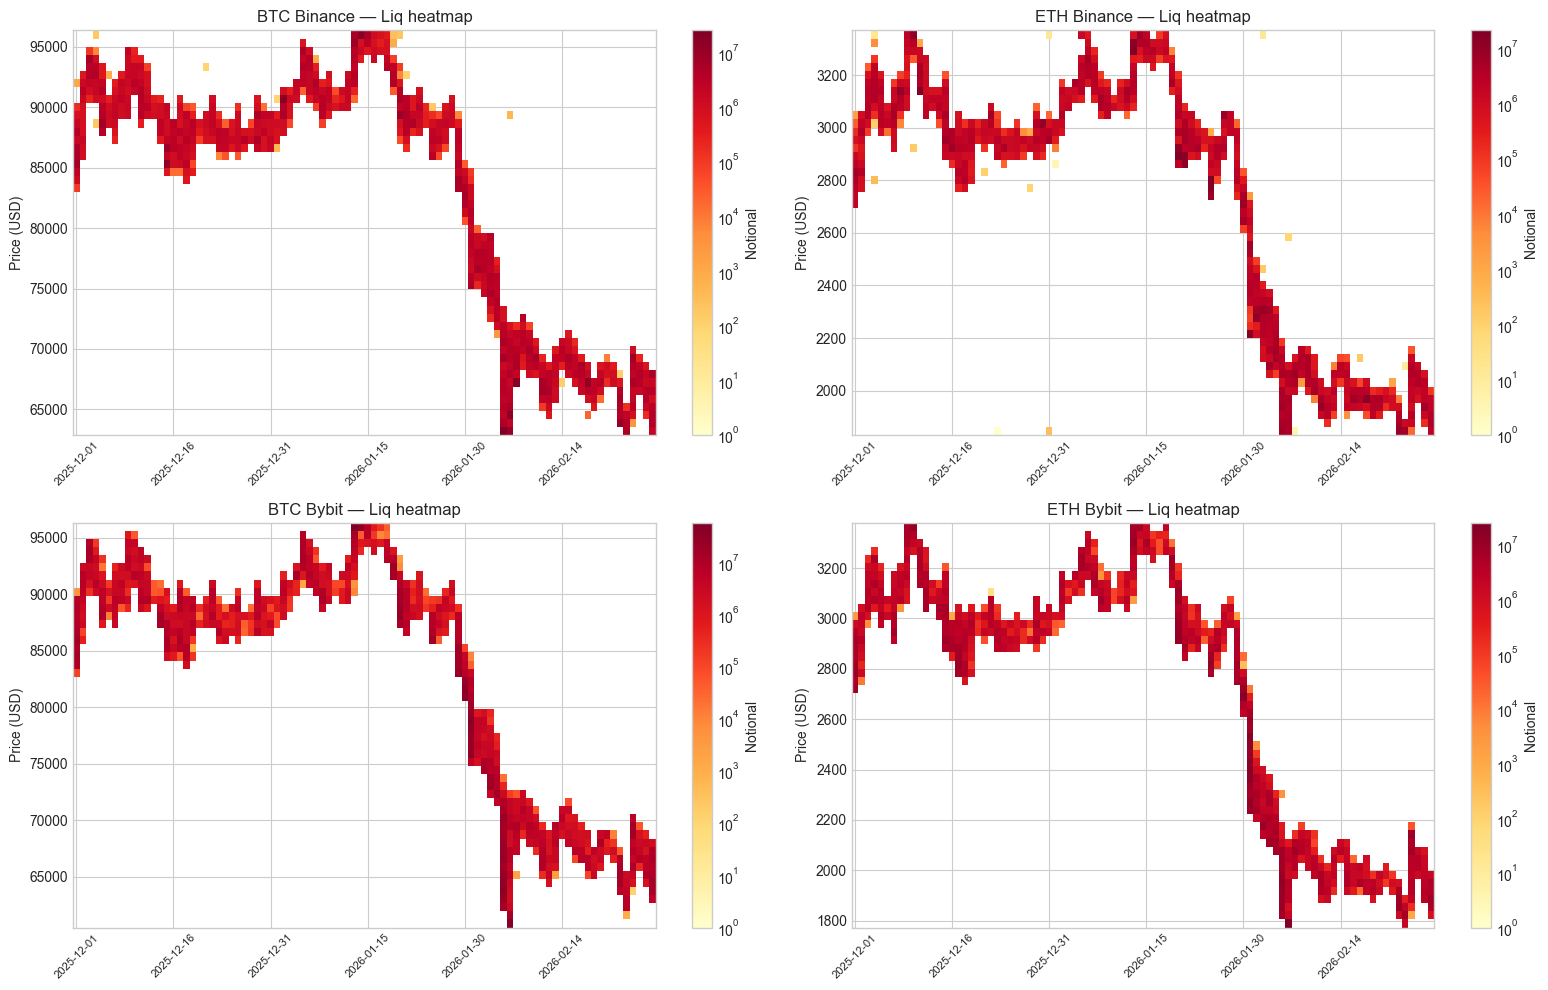

In [14]:
#1.3.3 Liquidation heatmap: price x date
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, sym in enumerate(['btc', 'eth']):
    for row, (exch, key) in enumerate([('Binance', f'lb_{sym}'), ('Bybit', f'ly_{sym}')]):
        df = pl.read_parquet(P[key]).with_columns([
            pl.col('timestamp').cast(pl.Datetime('us', 'UTC')).dt.date().alias('d'),
            (pl.col('price') * pl.col('amount')).alias('ntl'),
        ])
        prices = df['price'].to_numpy()
        pmin, pmax = np.percentile(prices, [1, 99])
        edges = np.linspace(pmin, pmax, 51)
        labels = (edges[:-1] + edges[1:]) / 2
        dates = sorted(df['d'].unique().to_list())
        d2i = {d: i for i, d in enumerate(dates)}

        hm = np.zeros((50, len(dates)))
        for r in df.iter_rows(named=True):
            di = d2i.get(r['d'])
            if di is None: continue
            pi = min(np.searchsorted(edges[1:], r['price']), 49)
            hm[pi, di] += r['ntl']

        ax = axes[row, col]
        hm_m = np.ma.masked_where(hm == 0, hm)
        im = ax.pcolormesh(range(len(dates)), labels, hm_m, norm=LogNorm(vmin=1, vmax=hm.max()), cmap='YlOrRd')
        ticks = list(range(0, len(dates), 15))
        ax.set_xticks(ticks); ax.set_xticklabels([str(dates[i]) for i in ticks], rotation=45, fontsize=8)
        ax.set(ylabel='Price (USD)', title=f'{sym.upper()} {exch} — Liq heatmap')
        plt.colorbar(im, ax=ax, label='Notional')
        del df
    gc.collect()

plt.tight_layout()
plt.show()

BTC: peak at lag=-1min (r=0.217), lag=0 r=0.192
ETH: peak at lag=0min (r=0.286), lag=0 r=0.286


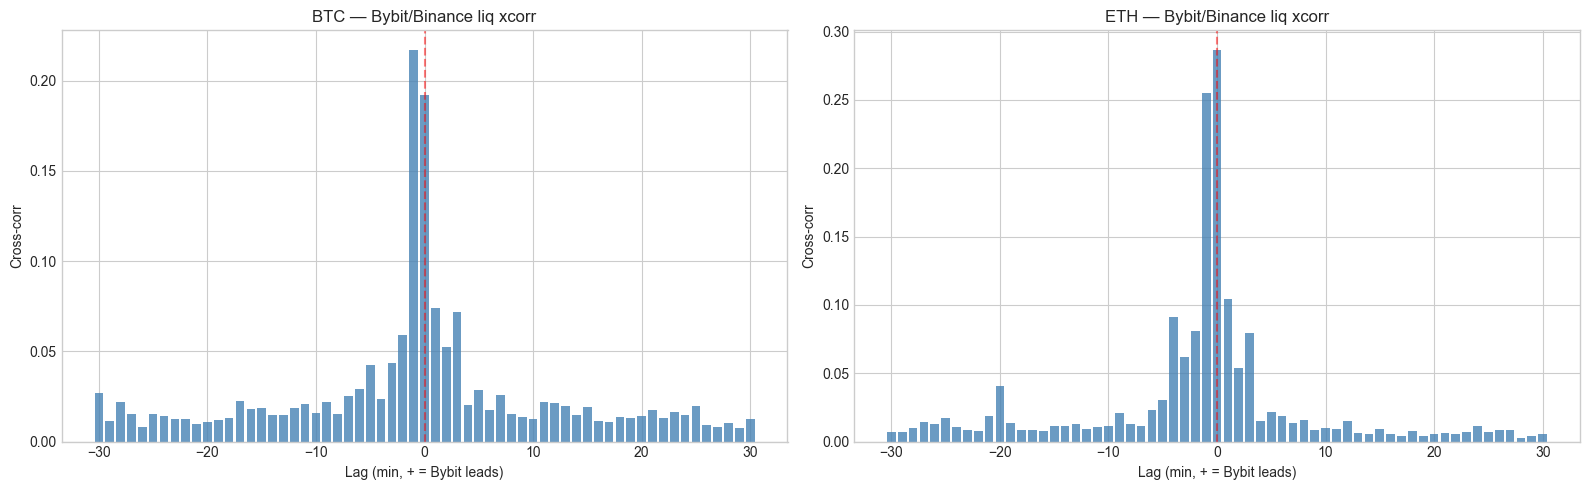

In [15]:
#1.3.4 Cross-exchange liquidation lead-lag
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col, sym in enumerate(['btc', 'eth']):
    bl = pl.read_parquet(P[f'lb_{sym}']).with_columns((pl.col('price') * pl.col('amount')).alias('ntl'))
    yl = pl.read_parquet(P[f'ly_{sym}']).sort('timestamp').with_columns((pl.col('price') * pl.col('amount')).alias('ntl'))

    bucket = 60000000  # 1min
    ts_min = min(bl['timestamp'].min(), yl['timestamp'].min())
    ts_max = max(bl['timestamp'].max(), yl['timestamp'].max())

    def to_buckets(ts_col, ntl_col):
        n = int((ts_max - ts_min) / bucket) + 1
        b = np.zeros(n)
        for ts, ntl in zip(ts_col.to_list(), ntl_col.to_list()):
            idx = int((ts - ts_min) / bucket)
            if 0 <= idx < n: b[idx] += ntl
        return b

    bs = to_buckets(bl['timestamp'], bl['ntl'])
    ys = to_buckets(yl['timestamp'], yl['ntl'])

    lags = list(range(-30, 31))
    xc = [np.corrcoef(ys[l:] if l >= 0 else ys[:len(ys)+l],
                       bs[:len(bs)-l] if l > 0 else bs[-l:] if l < 0 else bs)[0,1] for l in lags]

    axes[col].bar(lags, xc, color='steelblue', alpha=0.8)
    axes[col].axvline(0, color='red', ls='--', alpha=0.5)
    axes[col].set(xlabel='Lag (min, + = Bybit leads)', ylabel='Cross-corr', title=f'{sym.upper()} — Bybit/Binance liq xcorr')

    pk = lags[np.argmax(xc)]
    print(f"{sym.upper()}: peak at lag={pk}min (r={max(xc):.3f}), lag=0 r={xc[30]:.3f}")

    del bl, yl, bs, ys; gc.collect()

plt.tight_layout()
plt.show()


BTC: calm=26461 (5.3%), active=473539 (94.7%), heavy=48860 (9.8%)
  Calm    : t30=+1.490 t120=+0.881 t300=-0.501
  Active  : t30=+0.188 t120=+2.404 t300=+5.764
  Heavy   : t30=-3.269 t120=+0.154 t300=+3.256
  ALL     : t30=+0.257 t120=+2.324 t300=+5.432


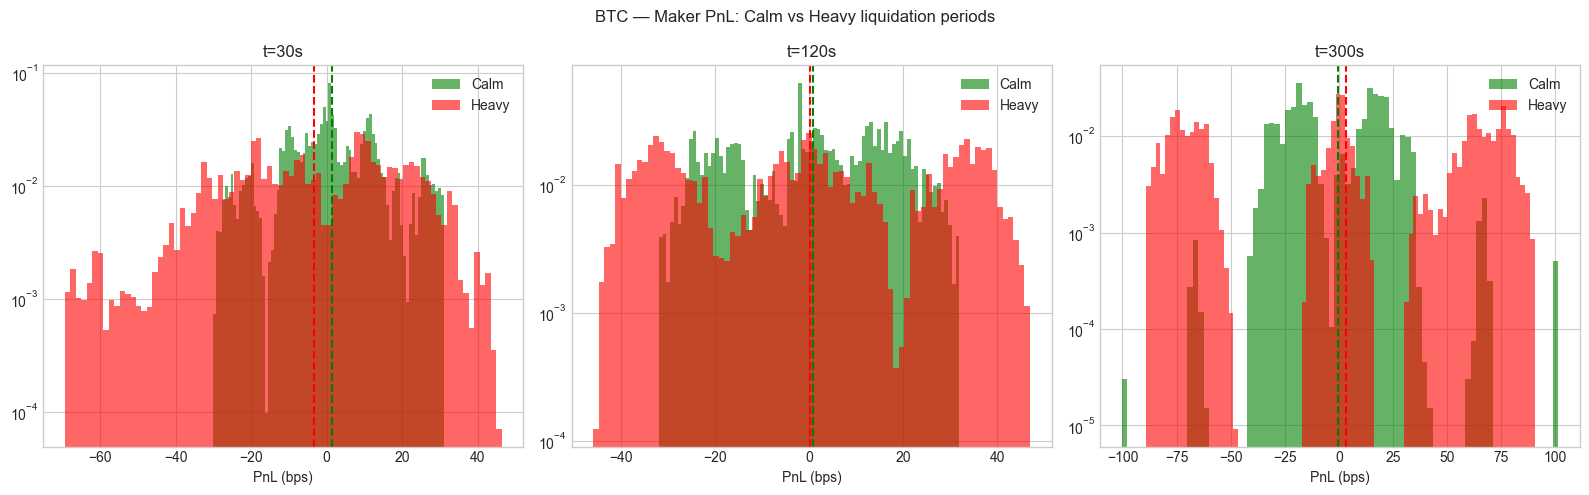


ETH: calm=3103 (0.6%), active=496897 (99.4%), heavy=52881 (10.6%)
  Calm    : t30=-2.723 t120=+2.151 t300=+19.046
  Active  : t30=-0.782 t120=+3.762 t300=+9.327
  Heavy   : t30=-3.611 t120=-0.761 t300=-0.864
  ALL     : t30=-0.794 t120=+3.752 t300=+9.388


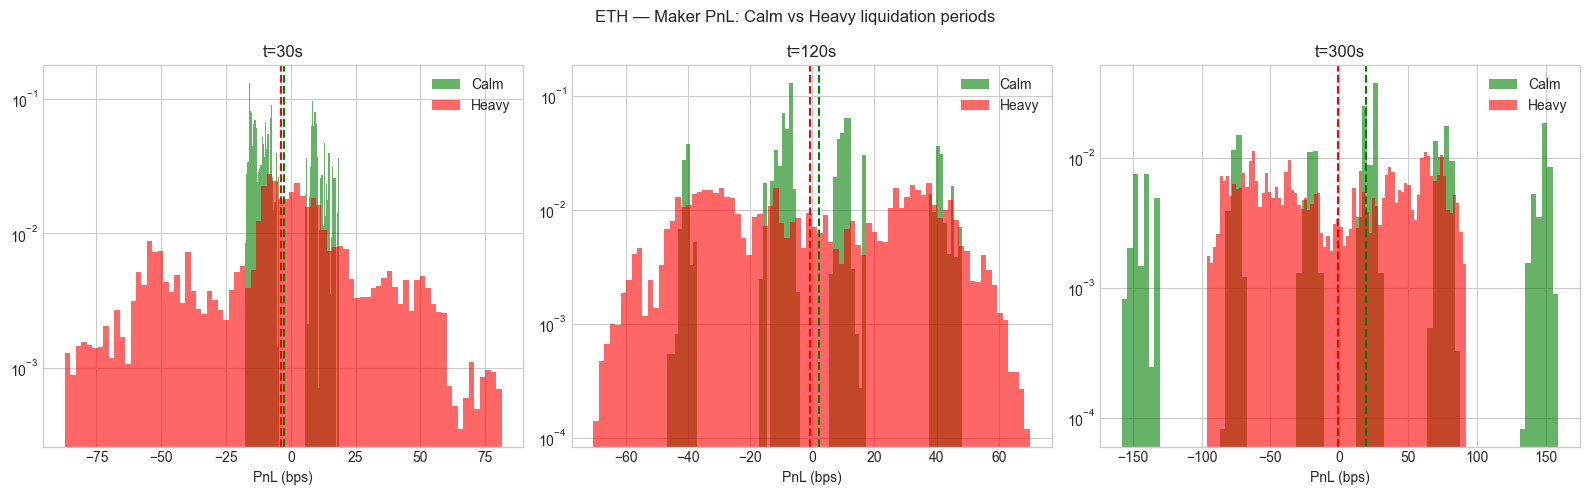

In [17]:
#1.3.5 Markout PnL conditioned on liquidation activity
for sym, tp, bp in [('BTC', P['tr_btc'], P['bbo_btc']), ('ETH', P['tr_eth'], P['bbo_eth'])]:
    trades = pl.read_parquet(tp, n_rows=500000)
    t_min, t_max = trades['timestamp'].min(), trades['timestamp'].max()

    bbo = pl.scan_parquet(bp).filter(
        (pl.col('timestamp') >= t_min) & (pl.col('timestamp') <= t_max + 301000000)
    ).select(['timestamp', 'bid_price', 'ask_price']).with_columns(
        ((pl.col('bid_price') + pl.col('ask_price'))/2).alias('mid')
    ).select(['timestamp', 'mid']).collect()

    liq_frames = []
    for key in [f'lb_{sym.lower()}', f'ly_{sym.lower()}']:
        lq = pl.read_parquet(P[key])
        if 'ly' in key: lq = lq.with_columns((pl.col('timestamp') + 200000).alias('timestamp'))
        lq = lq.filter((pl.col('timestamp') >= t_min) & (pl.col('timestamp') <= t_max))
        liq_frames.append(lq.with_columns((pl.col('price') * pl.col('amount')).alias('ntl')))
    all_liq = pl.concat(liq_frames).sort('timestamp')

    bts, bmid = bbo['timestamp'].to_numpy(), bbo['mid'].to_numpy()
    tts, tp_, tsd, ta = trades['timestamp'].to_numpy(), trades['price'].to_numpy(), trades['side'].to_list(), trades['amount'].to_numpy()
    lts, lntl = all_liq['timestamp'].to_numpy(), all_liq['ntl'].to_numpy()
    del trades, bbo, all_liq, liq_frames; gc.collect()

    res = []
    for i in range(len(tts)):
        t = tts[i]
        lv = lntl[np.searchsorted(lts, t - 60000000, side='left'):np.searchsorted(lts, t, side='right')].sum()
        si = -1 if tsd[i] == 'buy' else 1
        pnls = []
        for tau in [30, 120, 300]:
            idx = np.searchsorted(bts, t + tau * 1000000, side='right') - 1
            pnls.append(-si * (bmid[idx] - tp_[i]) / tp_[i] * 10000 + 0.5 if 0 <= idx < len(bmid) else np.nan)
        res.append((lv, *pnls))

    res = np.array(res)
    calm = res[:, 0] == 0
    active = res[:, 0] > 0
    heavy = res[:, 0] >= np.percentile(res[active, 0], 90) if active.sum() > 0 else np.zeros(len(res), dtype=bool)

    print(f"\n{sym}: calm={calm.sum()} ({calm.mean()*100:.1f}%), active={active.sum()} ({active.mean()*100:.1f}%), heavy={heavy.sum()} ({heavy.mean()*100:.1f}%)")
    for label, mask in [('Calm', calm), ('Active', active), ('Heavy', heavy), ('ALL', np.ones(len(res), bool))]:
        s = res[mask]; v = ~np.isnan(s).any(axis=1); s = s[v]
        if len(s) > 0:
            print(f"  {label:8s}: t30={s[:,1].mean():+.3f} t120={s[:,2].mean():+.3f} t300={s[:,3].mean():+.3f}")

    fig, axes_ = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{sym} — Maker PnL: Calm vs Heavy liquidation periods')
    for i, tau in enumerate([30, 120, 300]):
        ci = i + 1
        cp = res[calm & ~np.isnan(res[:, ci]), ci]
        hp = res[heavy & ~np.isnan(res[:, ci]), ci]
        axes_[i].hist(cp, bins=80, alpha=0.6, color='green', label=f'Calm', density=True, log=True)
        axes_[i].hist(hp, bins=80, alpha=0.6, color='red', label=f'Heavy', density=True, log=True)
        axes_[i].axvline(cp.mean(), color='green', ls='--'); axes_[i].axvline(hp.mean(), color='red', ls='--')
        axes_[i].set(xlabel='PnL (bps)', title=f't={tau}s'); axes_[i].legend()
    plt.tight_layout(); plt.show()

    del res, bts, bmid, tts, tp_, tsd, ta, lts, lntl; gc.collect()

BTC: 13921 buckets, VPIN mean=0.6358, p90=1.0000
ETH: 7063 buckets, VPIN mean=0.5683, p90=1.0000


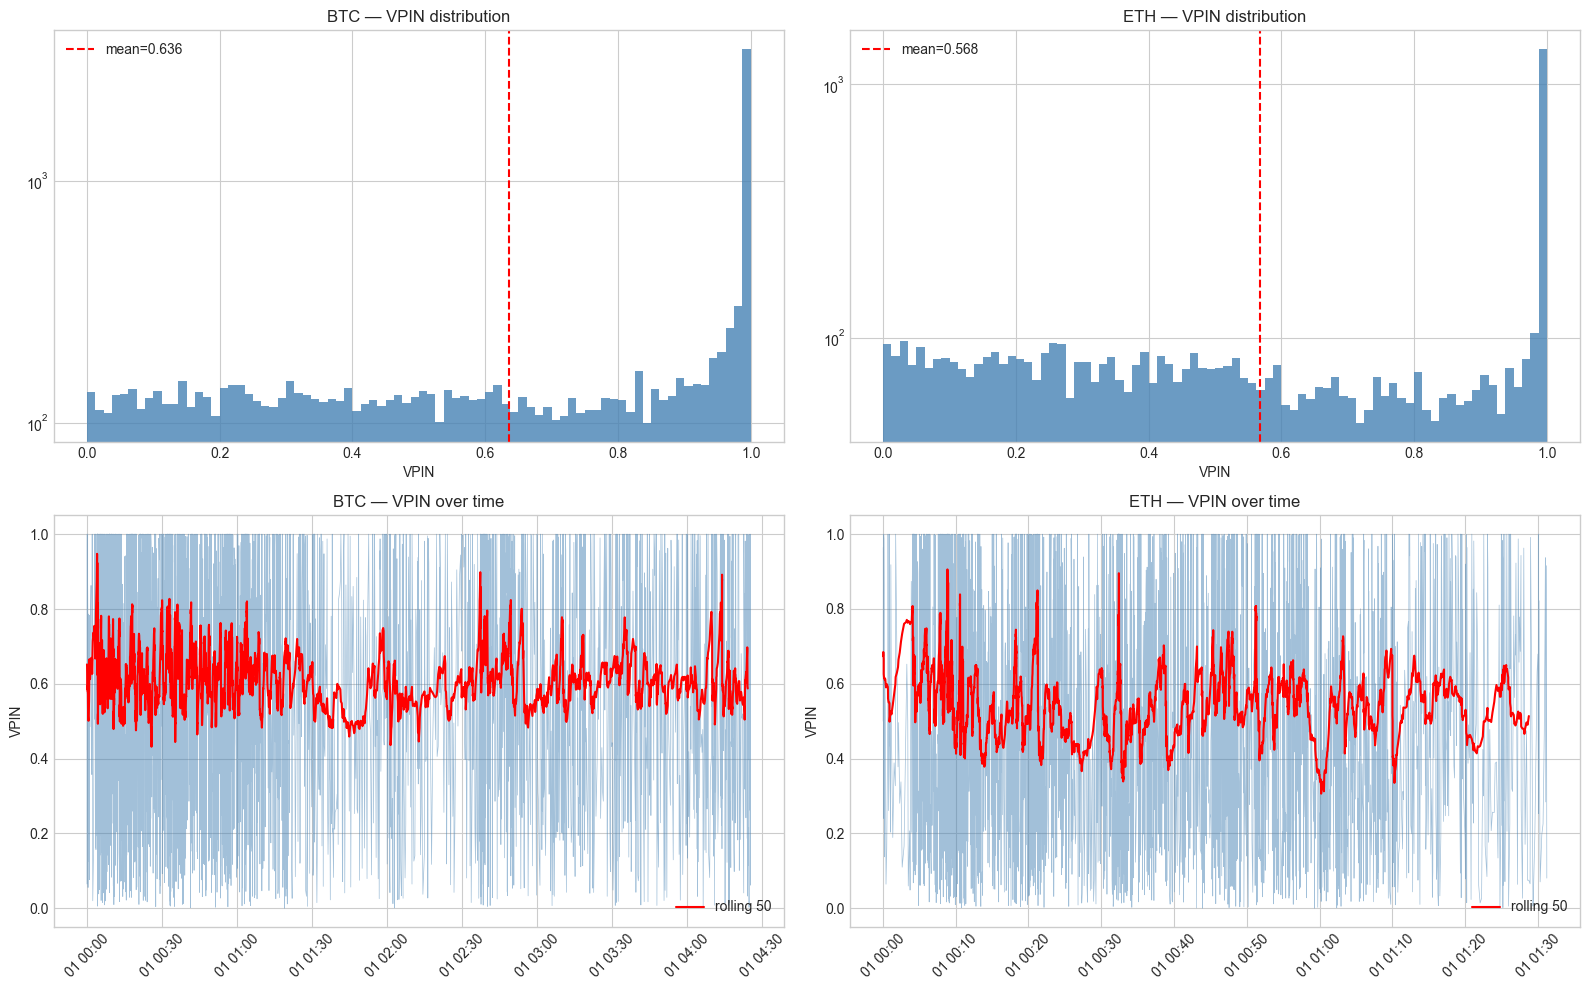

In [18]:
#1.3.6 Trade flow toxicity (VPIN)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (sym, path) in enumerate([('BTC', P['tr_btc']), ('ETH', P['tr_eth'])]):
    df = pl.read_parquet(path, n_rows=2000000).with_columns(
        (pl.col('price') * pl.col('amount')).alias('ntl')
    )
    ntl = df['ntl'].to_numpy()
    sides = df['side'].to_list()
    ts = df['timestamp'].to_numpy()
    del df; gc.collect()

    bucket_sz = 500000
    vpins, vts = [], []
    cb, cs, ct = 0, 0, 0
    for i in range(len(ntl)):
        if sides[i] == 'buy': cb += ntl[i]
        else: cs += ntl[i]
        ct += ntl[i]
        if ct >= bucket_sz:
            vpins.append(abs(cb - cs) / ct)
            vts.append(ts[i])
            cb, cs, ct = 0, 0, 0

    va = np.array(vpins)
    print(f"{sym}: {len(va)} buckets, VPIN mean={va.mean():.4f}, p90={np.percentile(va, 90):.4f}")

    axes[0, col].hist(va, bins=80, color='steelblue', alpha=0.8, log=True)
    axes[0, col].axvline(va.mean(), color='red', ls='--', label=f'mean={va.mean():.3f}')
    axes[0, col].set(xlabel='VPIN', title=f'{sym} — VPIN distribution'); axes[0, col].legend()

    step = max(1, len(vts)//3000)
    tdt = [ts2dt(t) for t in vts[::step]]
    axes[1, col].plot(tdt, va[::step], alpha=0.5, lw=0.5, color='steelblue')
    w = 50
    if len(va) > w:
        rm = np.convolve(va, np.ones(w)/w, mode='valid')
        axes[1, col].plot(tdt[:len(rm[::step])], rm[::step], color='red', lw=1.5, label=f'rolling {w}')
    axes[1, col].set(ylabel='VPIN', title=f'{sym} — VPIN over time'); axes[1, col].legend()
    axes[1, col].tick_params(axis='x', rotation=45)

    del ntl, sides, ts, va; gc.collect()

plt.tight_layout()
plt.show()


BTC — Feature correlation with markout PnL (299743 trades)
  spread_bps           | t30=-0.1302 | t120=-0.0297 | t300=+0.0168
  liq_vol_30s          | t30=-0.1525 | t120=-0.0591 | t300=-0.0189
  liq_vol_120s         | t30=-0.0935 | t120=-0.0265 | t300=-0.0038
  liq_imbalance        | t30=-0.0213 | t120=+0.0322 | t300=+0.0356
  notional             | t30=-0.0224 | t120=+0.0092 | t300=+0.0175
  volatility_30s       | t30=-0.1376 | t120=-0.0996 | t300=-0.0697


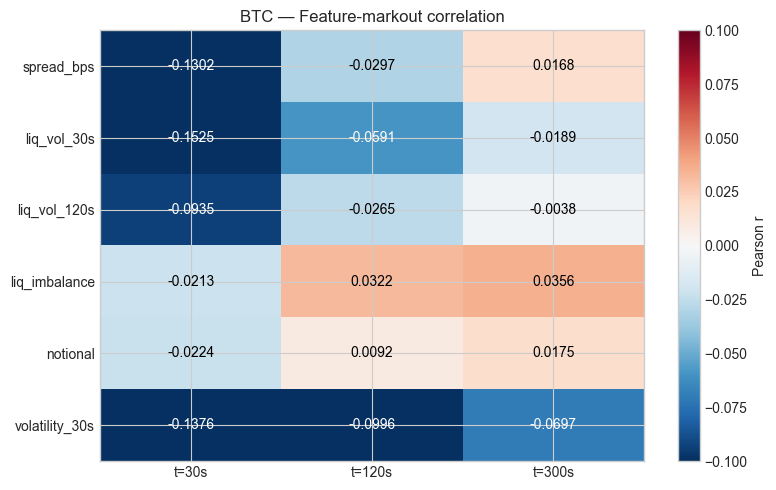


ETH — Feature correlation with markout PnL (299983 trades)
  spread_bps           | t30=-0.0734 | t120=-0.0148 | t300=-0.0019
  liq_vol_30s          | t30=-0.0754 | t120=-0.0915 | t300=-0.0746
  liq_vol_120s         | t30=-0.0520 | t120=-0.0724 | t300=-0.0813
  liq_imbalance        | t30=-0.0153 | t120=+0.0174 | t300=+0.0038
  notional             | t30=-0.0198 | t120=+0.0223 | t300=+0.0287
  volatility_30s       | t30=-0.0566 | t120=-0.0901 | t300=-0.0943


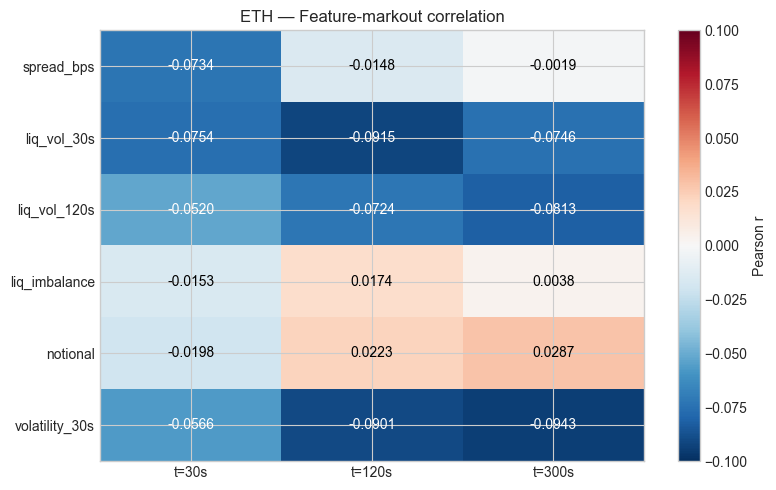

In [19]:
#1.3.7 Feature correlation with markout PnL
for sym, tp, bp in [('BTC', P['tr_btc'], P['bbo_btc']), ('ETH', P['tr_eth'], P['bbo_eth'])]:
    trades = pl.read_parquet(tp, n_rows=300000)
    t_min, t_max = trades['timestamp'].min(), trades['timestamp'].max()

    bbo = pl.scan_parquet(bp).filter(
        (pl.col('timestamp') >= t_min - 60000000) & (pl.col('timestamp') <= t_max + 301000000)
    ).select(['timestamp', 'bid_price', 'ask_price']).with_columns([
        ((pl.col('bid_price') + pl.col('ask_price'))/2).alias('mid'),
        (pl.col('ask_price') - pl.col('bid_price')).alias('spr'),
    ]).select(['timestamp', 'mid', 'spr']).collect()

    liq_frames = []
    for key in [f'lb_{sym.lower()}', f'ly_{sym.lower()}']:
        lq = pl.read_parquet(P[key])
        if 'ly' in key: lq = lq.with_columns((pl.col('timestamp') + 200000).alias('timestamp'))
        lq = lq.filter((pl.col('timestamp') >= t_min - 60000000) & (pl.col('timestamp') <= t_max))
        liq_frames.append(lq.with_columns((pl.col('price') * pl.col('amount')).alias('ntl')))
    all_liq = pl.concat(liq_frames).sort('timestamp')

    bts, bmid, bspr = bbo['timestamp'].to_numpy(), bbo['mid'].to_numpy(), bbo['spr'].to_numpy()
    tts, tp_, tsd, ta = trades['timestamp'].to_numpy(), trades['price'].to_numpy(), trades['side'].to_list(), trades['amount'].to_numpy()
    lts, lntl, lsd = all_liq['timestamp'].to_numpy(), all_liq['ntl'].to_numpy(), all_liq['side'].to_list()
    del trades, bbo, all_liq, liq_frames; gc.collect()

    feats, tgts = [], {30: [], 120: [], 300: []}
    for i in range(len(tts)):
        t = tts[i]
        bi = np.searchsorted(bts, t, side='right') - 1
        if bi < 0 or bi >= len(bmid): continue
        spr_bps = bspr[bi] / bmid[bi] * 10000 if bmid[bi] > 0 else 0

        l30s = np.searchsorted(lts, t - 30000000, side='left')
        l120s = np.searchsorted(lts, t - 120000000, side='left')
        le = np.searchsorted(lts, t, side='right')
        lv30 = lntl[l30s:le].sum()
        lv120 = lntl[l120s:le].sum()

        l60s = np.searchsorted(lts, t - 60000000, side='left')
        sl = lsd[l60s:le]; sn = lntl[l60s:le]
        bv = sum(n for s, n in zip(sl, sn) if s == 'buy')
        sv = sum(n for s, n in zip(sl, sn) if s == 'sell')
        limb = (sv - bv) / (sv + bv + 1)

        bstart = np.searchsorted(bts, t - 30000000, side='left')
        rm = bmid[bstart:bi+1]
        vol30 = np.diff(np.log(rm)).std() * 10000 if len(rm) > 5 else 0

        feats.append([spr_bps, lv30, lv120, limb, min(tp_[i] * ta[i], 100000), vol30])
        si = -1 if tsd[i] == 'buy' else 1
        for tau in [30, 120, 300]:
            idx = np.searchsorted(bts, t + tau * 1000000, side='right') - 1
            tgts[tau].append(-si * (bmid[idx] - tp_[i]) / tp_[i] * 10000 + 0.5 if 0 <= idx < len(bmid) else np.nan)

    feats = np.array(feats)
    fnames = ['spread_bps', 'liq_vol_30s', 'liq_vol_120s', 'liq_imbalance', 'notional', 'volatility_30s']

    print(f"\n{sym} — Feature correlation with markout PnL ({len(feats)} trades)")
    cm = {}
    for j, fn in enumerate(fnames):
        cs = {}
        for tau in [30, 120, 300]:
            tgt = np.array(tgts[tau])
            v = ~np.isnan(tgt) & ~np.isnan(feats[:, j])
            cs[tau] = np.corrcoef(feats[v, j], tgt[v])[0, 1] if v.sum() > 100 else 0
        cm[fn] = cs
        print(f"  {fn:20s} | t30={cs[30]:+.4f} | t120={cs[120]:+.4f} | t300={cs[300]:+.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    cd = np.array([[cm[f][t] for t in [30, 120, 300]] for f in fnames])
    im = ax.imshow(cd, cmap='RdBu_r', vmin=-0.1, vmax=0.1, aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(['t=30s', 't=120s', 't=300s'])
    ax.set_yticks(range(len(fnames))); ax.set_yticklabels(fnames)
    ax.set_title(f'{sym} — Feature-markout correlation')
    for ii in range(len(fnames)):
        for jj in range(3):
            ax.text(jj, ii, f'{cd[ii,jj]:.4f}', ha='center', va='center', fontsize=10,
                   color='white' if abs(cd[ii,jj]) > 0.05 else 'black')
    plt.colorbar(im, label='Pearson r')
    plt.tight_layout(); plt.show()

    del feats, tgts, bts, bmid, bspr, tts, tp_, tsd, ta, lts, lntl, lsd; gc.collect()

### Summary Task 1.3

Hypotheses tested:

H1: Liquidations cause directional price impact.
Confirmed. Sell liquidations preceded by price drops, buy by price rises. Partial mean-reversion after 10s.
Large liquidations (Q4) show 3–5× more impact than small (Q1) — non-linear relationship.

H2: Maker PnL is worse during liquidation bursts.
Confirmed. BTC: calm periods t=30s = +1.49 bps vs heavy periods = −3.27 bps (4.76 bps difference).
ETH heavy periods negative at all horizons (−3.6, −0.8, −0.9 bps). This validates the filtering hypothesis.

H3: Bybit liquidations lead Binance (cross-exchange signal).
Rejected. BTC peak xcorr at lag=−1min (Binance slightly leads), ETH at lag=0.
No predictive signal from Bybit → Binance. Bursts are simultaneous — driven by common market moves.

H4: Flow toxicity (VPIN) is elevated in these markets.
Confirmed. Mean VPIN 0.57–0.64, p90=1.0 — high baseline, with frequent fully one-sided volume buckets.

H5: Liquidation activity and volatility are the strongest predictors of adverse selection.
Confirmed. Top features correlated with worse maker PnL at t=30s:
liq_vol_30s r=−0.15, volatility_30s r=−0.14, spread_bps r=−0.13.
All negatively correlated — optimal filter should combine these three features.


## Executive Summary

### Data
- 89 days of Binance BTC/ETH perpetual futures: 1.1B trades, 207M BBO updates, 635K liquidations.
- Clean dataset: zero nulls, all prices positive. Minor Bybit sorting issues (63/46 out-of-order rows).

### Market Structure
- Ultra-liquid: spreads 0.01–0.04 bps, 50–90 trades/sec. Symmetric taker flow (buy ratio 0.50).
- Strong volatility clustering (|return| ACF = 0.35 at 1s, persists 5+ min) — 14% time in high-vol regime.
- Daily volume: BTC $13.4B ± $6.9B, ETH $12.2B ± $5.9B — high day-to-day variance.

### Liquidation Dynamics
- Rare events (0.02/sec) but highly correlated across exchanges (ρ = 0.83–0.89).
- Sell-dominated (2:1 ratio) — persistent long-side bias among retail traders.
- Bybit: 2× more events; Binance: larger single events (max $15M vs $3.4M).
- Cross-exchange bursts are near-simultaneous — no lead-lag arbitrage signal.

### Target Analysis
- Maker PnL at t=30s is negative (−0.3 bps) — adverse selection dominates despite rebate.
- At t=120/300s: positive (5–22 bps) — mean-reversion at longer horizons.
- During heavy liquidation periods, maker PnL drops by 5 bps: direct evidence that filtering is beneficial.

### Signal Construction Implications
- Primary features: rolling liquidation volume, short-term volatility, spread width.
- Filter quotes during liquidation bursts — highest adverse selection cost.
- Volatility regime as context — high-vol periods amplify adverse selection.
- Liquidation side asymmetry — sell-heavy periods may warrant asymmetric quoting.

### Limitations
- Some analyses use subsamples (200–500K rows) due to memory constraints (8GB RAM).
- 3-month window only; regime patterns may differ across market cycles.
- Bybit data lacks trades/BBO — liquidation observations only.
- 200ms Bybit timestamp correction is assumed fixed; actual network latency may vary.
- Markout PnL computed on first 200–500K trades only, not full dataset.